# Import Libraries
Import all necessary libraries for data processing and visualization including pandas, numpy, matplotlib, seaborn, and datetime-related utilities.

In [5]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

# Set plotting style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(font_scale=1.2)
np.random.seed(42)  # For reproducibility

# Define Project Paths
Set up path variables for project root, data directories, and output locations.

In [6]:
# Define Project Paths
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "."))
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "data/analysis"

# Ensure directories exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Display the paths
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")

Project Root: /project
Data Directory: /project/data
Models Directory: /project/models
Output Directory: /project/data/analysis


# Load Raw Data
Load the raw incidents, socioeconomic, and weather datasets from CSV files.

In [7]:
# Load Raw Data
incidents_df = pd.read_csv(DATA_DIR / 'processed/incidents.csv')
socio_df = pd.read_csv(DATA_DIR / 'processed/socioeconomic_counties.csv')
weather_df = pd.read_csv(DATA_DIR / 'processed/weather_daily.csv')

# Convert datetime columns to datetime format
incidents_df['datetime'] = pd.to_datetime(incidents_df['datetime'])
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Filter data for the years 2020 and later
socio_df = socio_df[socio_df.year >= 2020]
weather_df = weather_df[weather_df.date.dt.year >= 2020]

# Display the first few rows of each dataframe
print("Incidents DataFrame:")
print(incidents_df.head())
print("\nSocioeconomic DataFrame:")
print(socio_df.head())
print("\nWeather DataFrame:")
print(weather_df.head())

/tmp/ipykernel_14202/4077854398.py:2: DtypeWarning: Columns (9,10,11,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  incidents_df = pd.read_csv(DATA_DIR / 'processed/incidents.csv')


Incidents DataFrame:
          id            datetime  longitude   latitude          voivodeship  \
0  108526474 2020-01-01 00:15:00  16.761389  52.514028        wielkopolskie   
1  108526534 2020-01-01 00:20:00  18.953917  51.895527              łódzkie   
2  108523125 2020-01-01 00:25:00  14.568027  53.435666   zachodniopomorskie   
3  108523133 2020-01-01 00:55:00  20.929499  53.849416  warmińsko-mazurskie   
4  108526549 2020-01-01 01:20:00  23.047500  53.405555            podlaskie   

       county municipality                      city  \
0   poznański   Rokietnica                Rokietnica   
1  poddębicki    Poddębice                 Poddębice   
2    Szczecin     Szczecin                  Szczecin   
3  olsztyński    Biskupiec                     Rzeck   
4    moniecki   Jasionówka  Brak w danych źródłowych   

               incident_type other_cause  ... vehicle_types_trucks  \
0     Najechanie na pieszego        Brak  ...              43349.0   
1     Najechanie na pieszeg

# Initial Data Exploration
Perform initial exploration of the raw datasets to understand their structure, check for missing values, and examine data types.

Incidents DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88607 entries, 0 to 88606
Data columns (total 40 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   id                                                                  88607 non-null  int64         
 1   datetime                                                            88607 non-null  datetime64[ns]
 2   longitude                                                           88607 non-null  float64       
 3   latitude                                                            88607 non-null  float64       
 4   voivodeship                                                         88607 non-null  object        
 5   county                                                              88607 non-null  object        
 6   municipality                

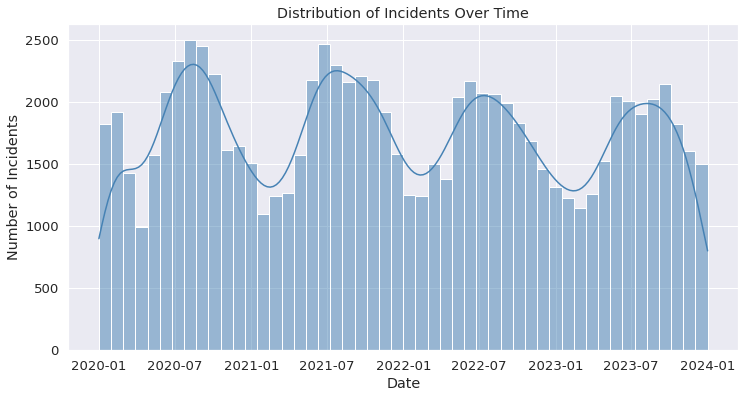

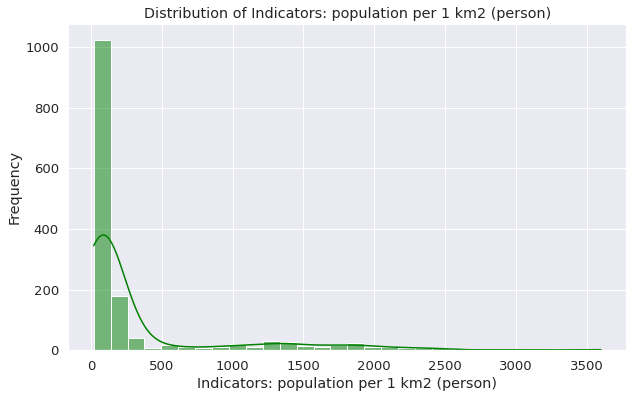

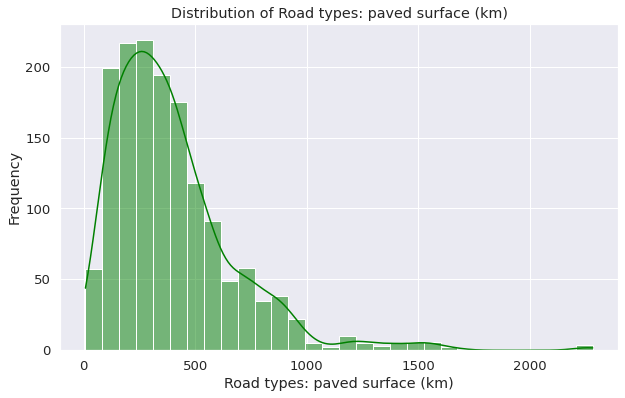

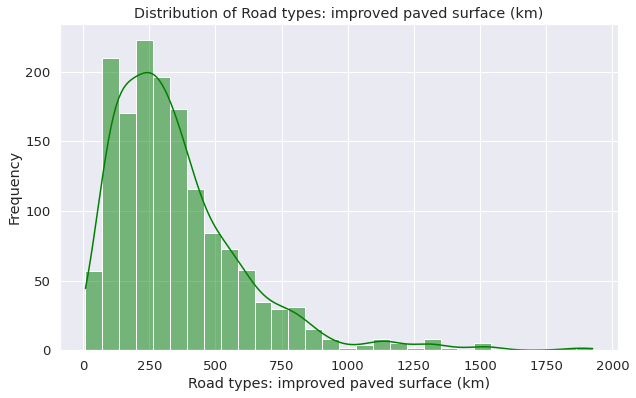

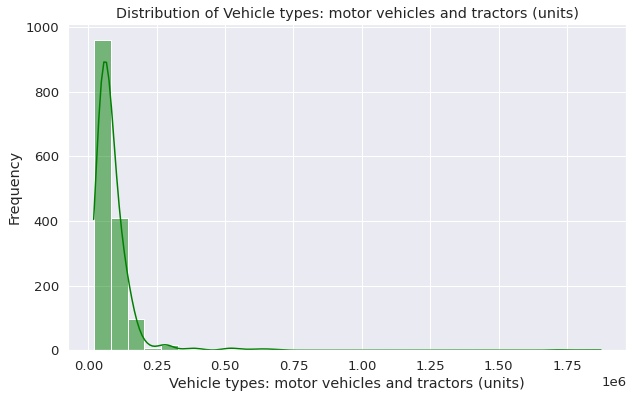

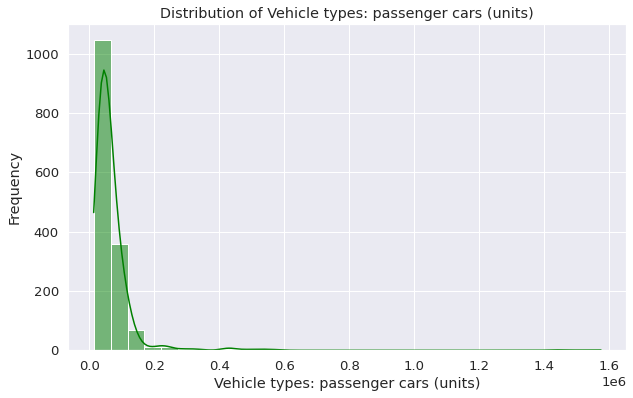

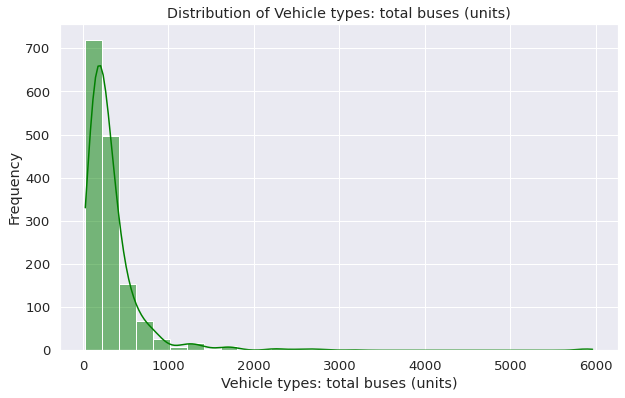

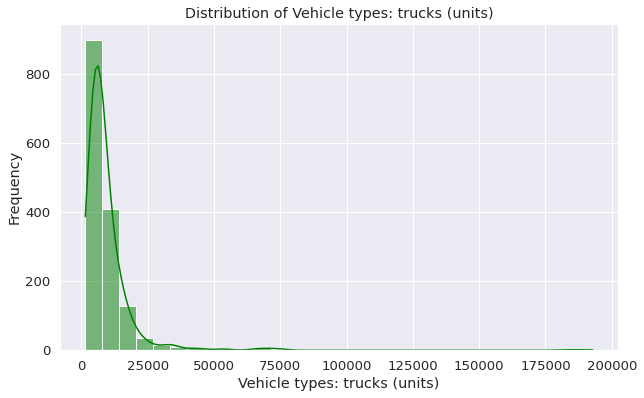

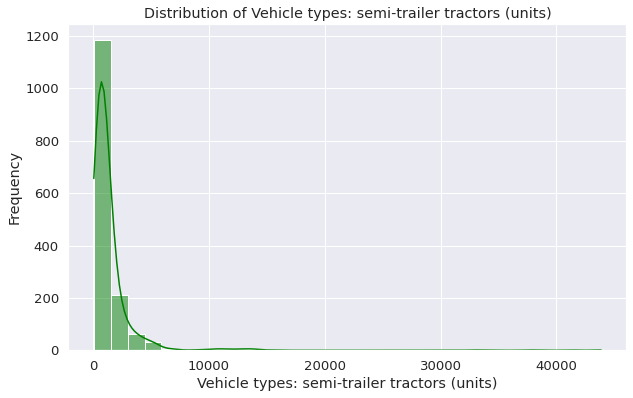

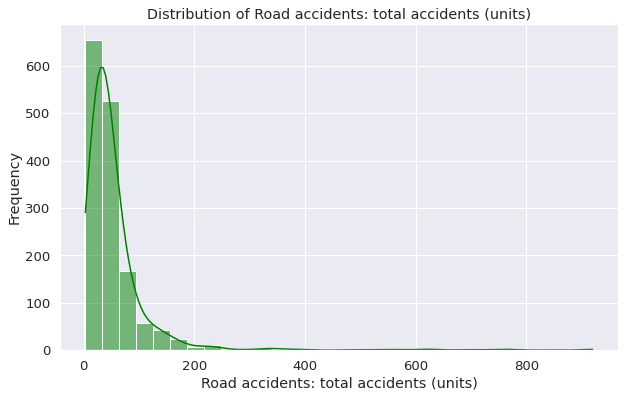

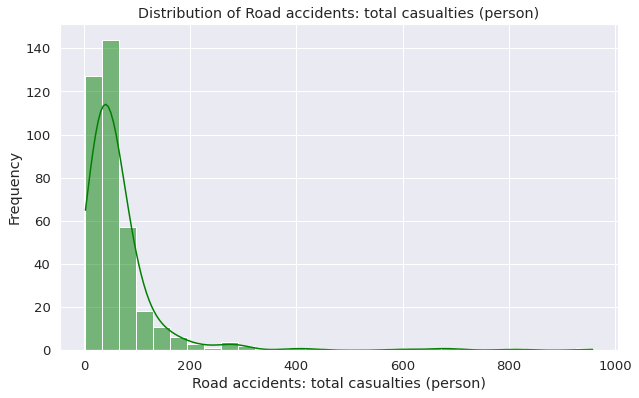

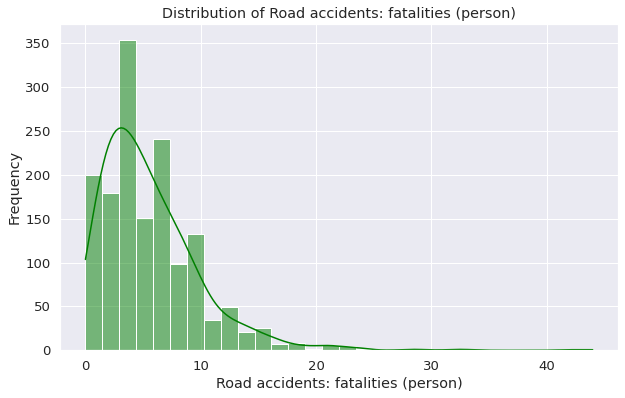

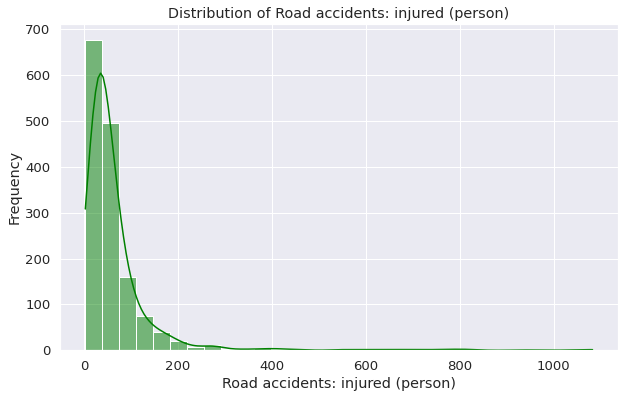

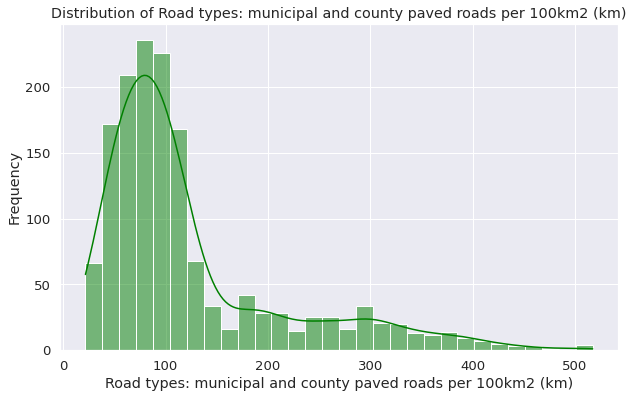

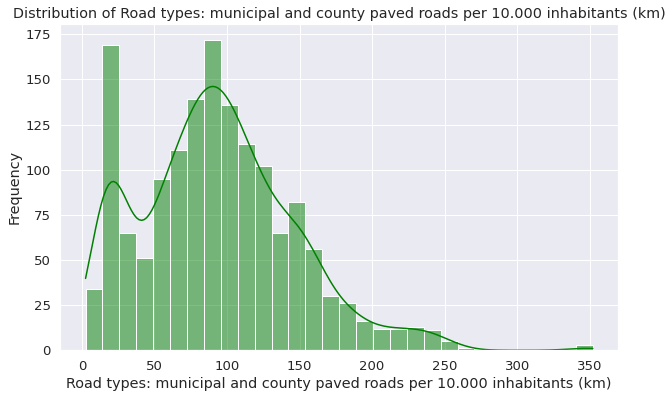

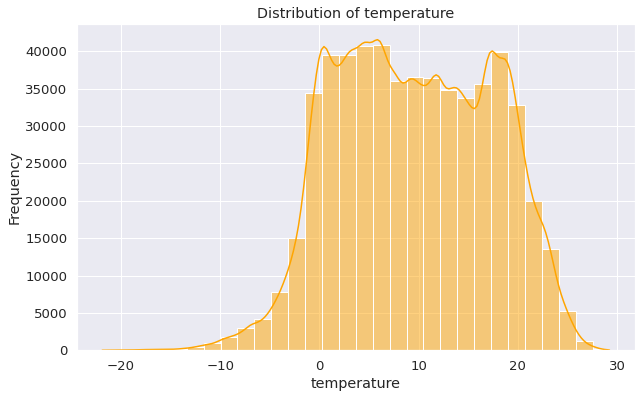

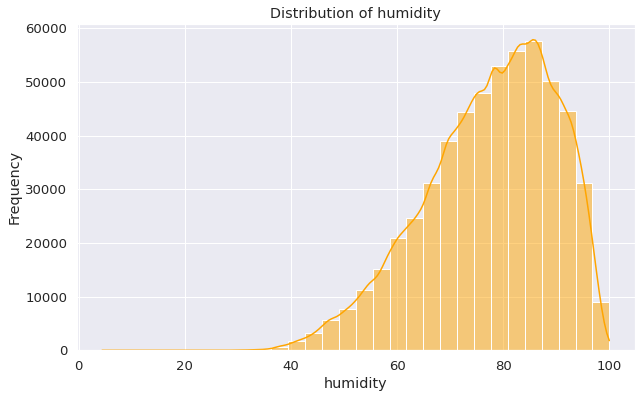

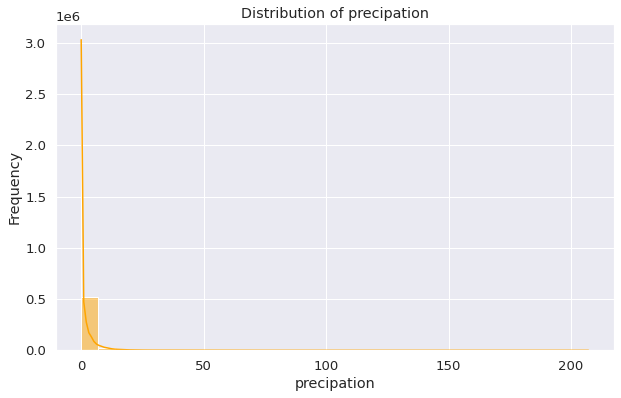

In [8]:
# Initial Data Exploration

# Display basic information about each dataframe
print("Incidents DataFrame Info:")
print(incidents_df.info())
print("\nSocioeconomic DataFrame Info:")
print(socio_df.info())
print("\nWeather DataFrame Info:")
print(weather_df.info())

# Check for missing values in each dataframe
print("\nMissing Values in Incidents DataFrame:")
print(incidents_df.isnull().sum())
print("\nMissing Values in Socioeconomic DataFrame:")
print(socio_df.isnull().sum())
print("\nMissing Values in Weather DataFrame:")
print(weather_df.isnull().sum())

# Visualize the distribution of incidents over time
plt.figure(figsize=(12, 6))
sns.histplot(incidents_df['datetime'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Incidents Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Incidents')
plt.show()

# Visualize the distribution of socioeconomic data
socio_cols = socio_df.columns[3:]  # Assuming first three columns are identifiers
for col in socio_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(socio_df[col], bins=30, kde=True, color='green')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Visualize the distribution of weather data
weather_cols = ['temperature', 'humidity', 'precipation']
for col in weather_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(weather_df[col], bins=30, kde=True, color='orange')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Create Monthly Aggregations
Process incidents data by month, aggregate weather data monthly, and merge with socioeconomic data to create a comprehensive monthly dataset.

Analysis DataFrame Shape: (18288, 23)
           county voivodeship  year  month  mean_temperature  mean_humidity  \
0  Biała Podlaska   lubelskie  2020      1          1.766549      87.262311   
1  Biała Podlaska   lubelskie  2020      2          3.403419      79.903982   
2  Biała Podlaska   lubelskie  2020      3          4.322717      67.039460   
3  Biała Podlaska   lubelskie  2020      4          8.393013      53.479994   
4  Biała Podlaska   lubelskie  2020      5         11.278060      71.415718   

   total_precipitation  incident_count  \
0            14.090505               2   
1            48.421234               3   
2            15.116825               2   
3             5.458434               0   
4            87.556506               1   

   Indicators: population per 1 km2 (person)  Road types: paved surface (km)  \
0                                     1124.1                           111.5   
1                                     1124.1                           111

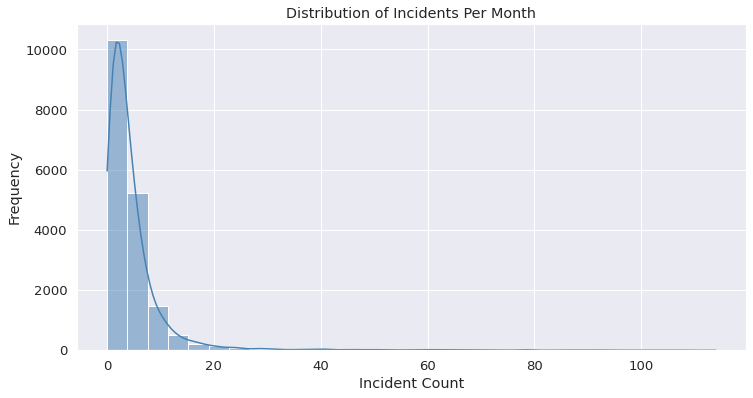

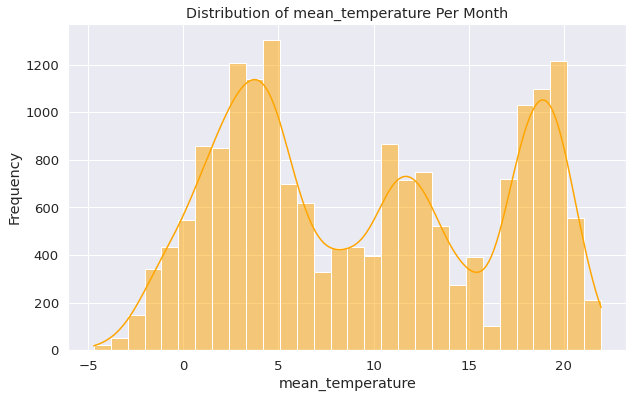

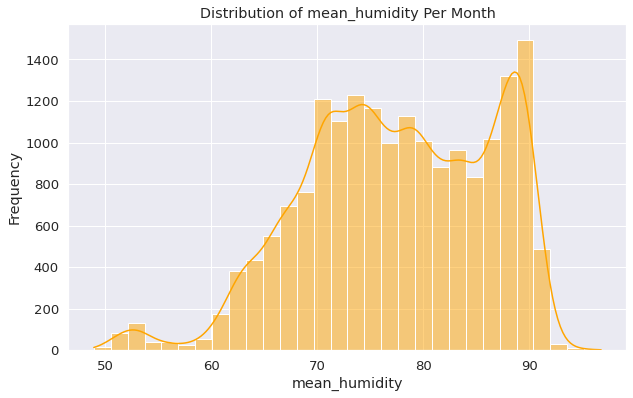

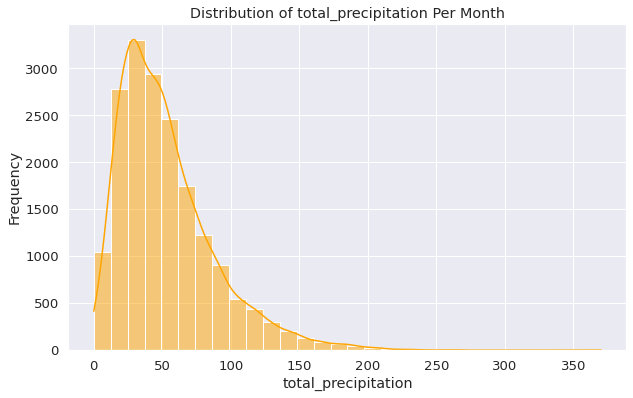

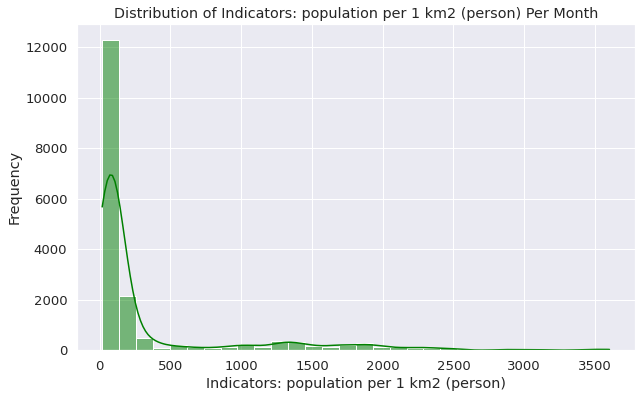

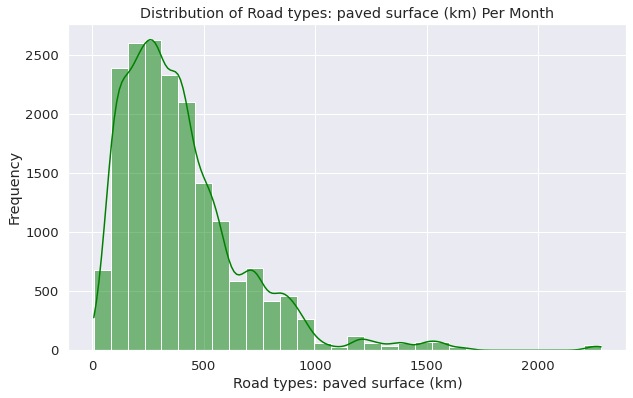

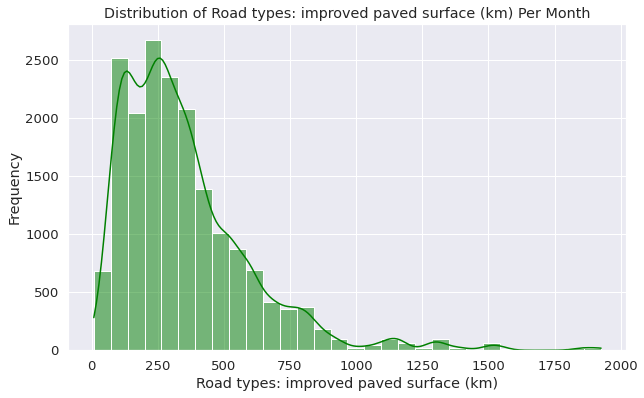

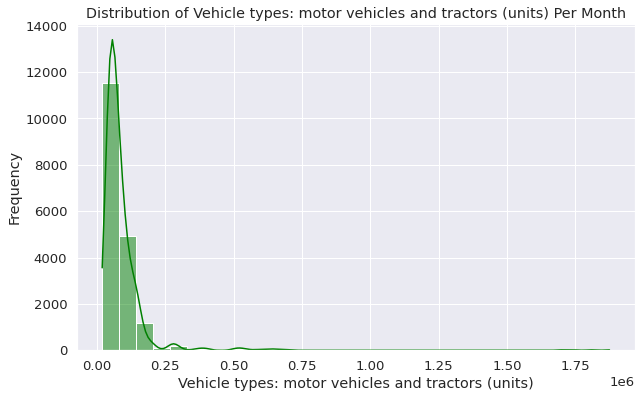

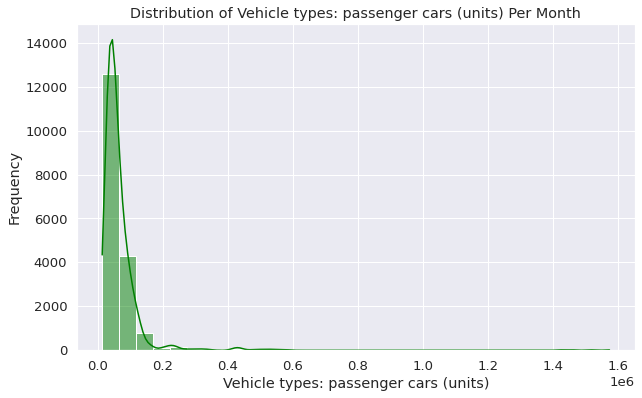

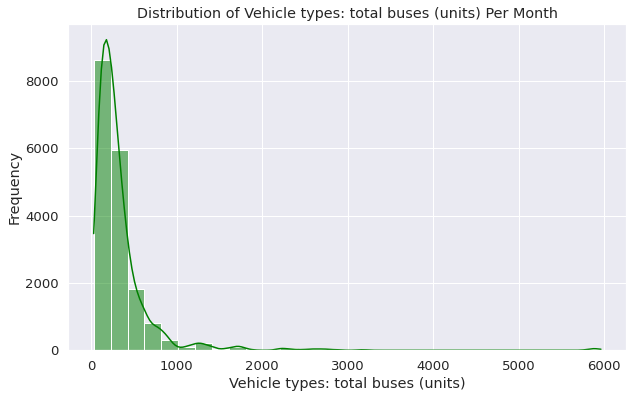

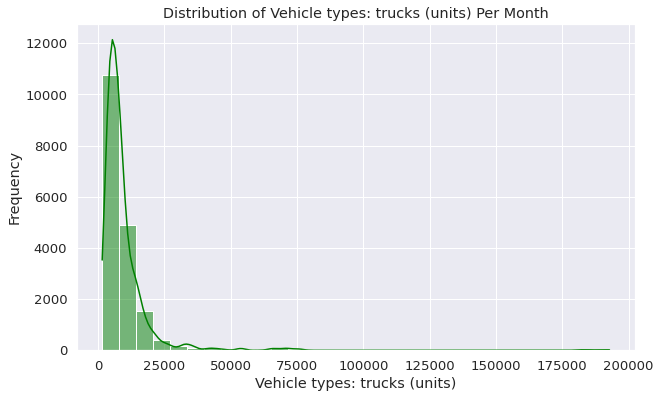

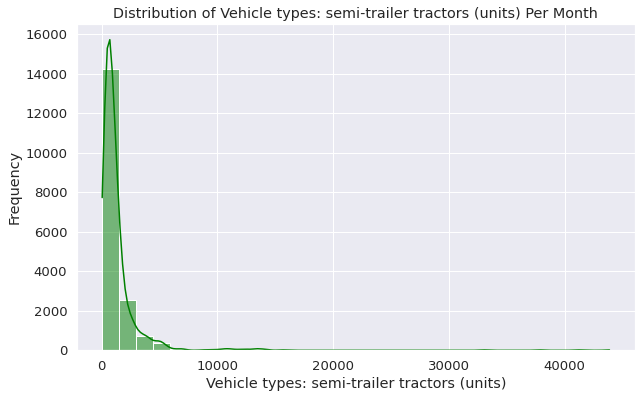

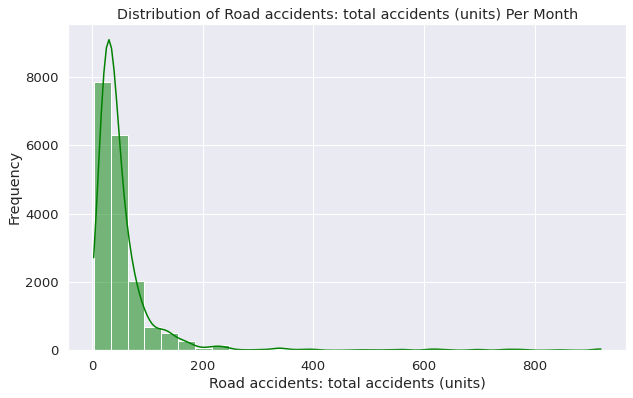

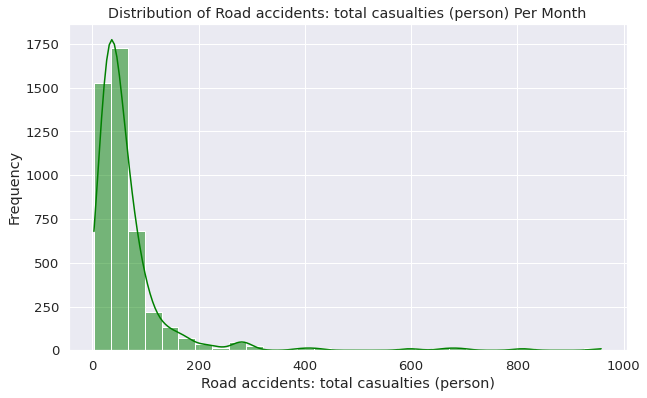

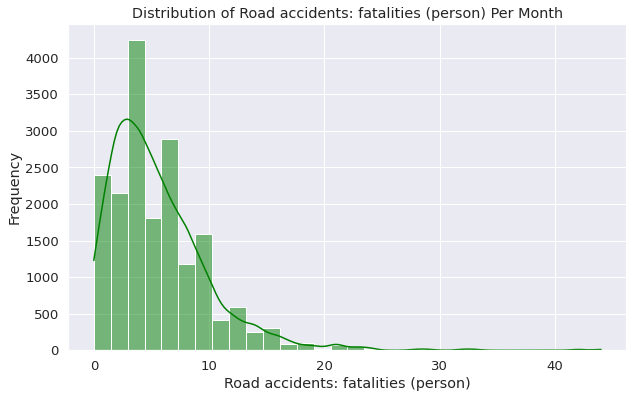

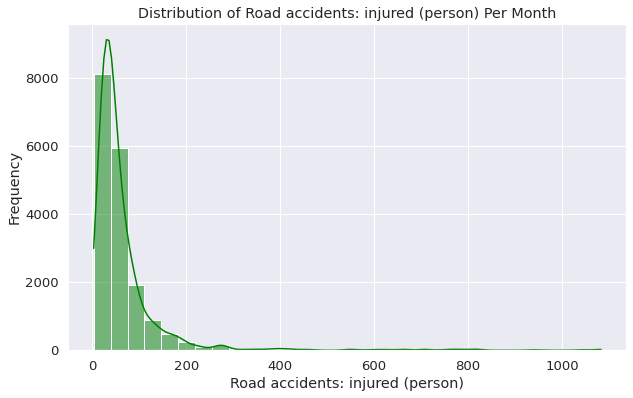

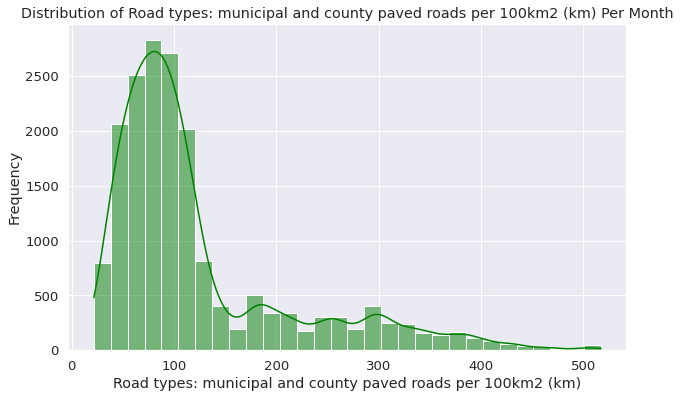

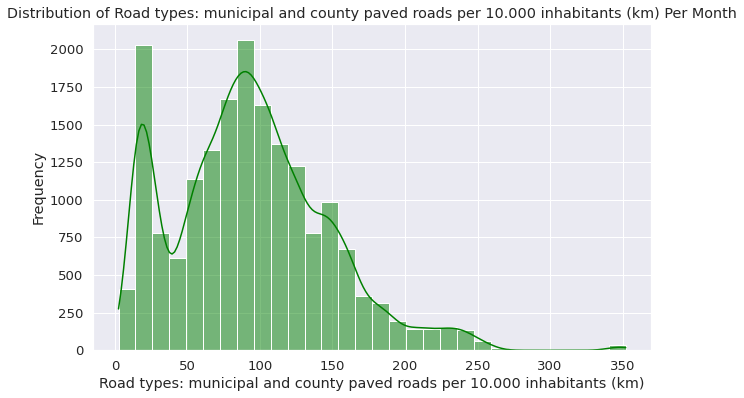

In [9]:
# Create Monthly Aggregations

# Step 1: Process incidents data
# Convert datetime to datetime format and extract year/month
incidents_df['year'] = incidents_df['datetime'].dt.year
incidents_df['month'] = incidents_df['datetime'].dt.month

# Count incidents per county per month
incidents_count = incidents_df.groupby(['county', 'voivodeship', 'year', 'month']).size().reset_index(name='incident_count')

# Step 2: Process weather data
# Convert date to datetime and extract year/month
weather_df['year'] = weather_df['date'].dt.year
weather_df['month'] = weather_df['date'].dt.month

# Calculate monthly weather statistics (mean temp/humidity and sum precipitation)
weather_monthly = weather_df.groupby(['county', 'voivodeship', 'year', 'month']).agg({
    'temperature': 'mean',
    'humidity': 'mean',
    'precipation': 'sum'
}).reset_index()

# Step 3: Process socioeconomic data
# Ensure year is numeric
socio_df['year'] = pd.to_numeric(socio_df['year'])

# Step 4: Create analysis dataframe
# Use weather data as our base to ensure we have weather metrics for all entries
analysis_monthly_df = weather_monthly.copy()

# Merge with incident counts (left join to keep all weather entries)
analysis_monthly_df = pd.merge(
    analysis_monthly_df,
    incidents_count,
    on=['county', 'voivodeship', 'year', 'month'],
    how='left'
)

# Fill missing incident counts with 0 (counties with no incidents that month)
analysis_monthly_df['incident_count'] = analysis_monthly_df['incident_count'].fillna(0).astype(int)

# Merge with socioeconomic data
# The socioeconomic data will naturally repeat for all months in the same year
analysis_monthly_df = pd.merge(
    analysis_monthly_df,
    socio_df,
    on=['county', 'voivodeship', 'year'],
    how='left'
)

# Rename columns for clarity
analysis_monthly_df = analysis_monthly_df.rename(columns={
    'temperature': 'mean_temperature',
    'humidity': 'mean_humidity',
    'precipation': 'total_precipitation'
})

# Create a year_month column for easier analysis
analysis_monthly_df['year_month'] = analysis_monthly_df['year'].astype(str) + '-' + analysis_monthly_df['month'].astype(str).str.zfill(2)

# Display the result shape and first few rows
print(f"Analysis DataFrame Shape: {analysis_monthly_df.shape}")
print(analysis_monthly_df.head())

# Visualize the distribution of incidents per month
plt.figure(figsize=(12, 6))
sns.histplot(analysis_monthly_df['incident_count'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Incidents Per Month')
plt.xlabel('Incident Count')
plt.ylabel('Frequency')
plt.show()

# Visualize the distribution of weather data per month
weather_cols = ['mean_temperature', 'mean_humidity', 'total_precipitation']
for col in weather_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(analysis_monthly_df[col], bins=30, kde=True, color='orange')
    plt.title(f'Distribution of {col} Per Month')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Visualize the distribution of socioeconomic data per month
socio_cols = socio_df.columns[3:]  # Assuming first three columns are identifiers
for col in socio_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(analysis_monthly_df[col], bins=30, kde=True, color='green')
    plt.title(f'Distribution of {col} Per Month')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Create Yearly Aggregations
Aggregate incident counts and weather metrics by year, and merge with socioeconomic data to create a yearly analysis dataset.

Yearly Analysis DataFrame Shape: (1524, 21)
           county voivodeship  year  mean_temperature  mean_humidity  \
0  Biała Podlaska   lubelskie  2020          9.913629      77.586073   
1  Biała Podlaska   lubelskie  2021          8.327231      79.292413   
2  Biała Podlaska   lubelskie  2022          9.169254      77.391236   
3  Biała Podlaska   lubelskie  2023         10.025624      77.269007   
4       Białystok   podlaskie  2020          9.626115      78.142038   

   total_precipitation  incident_count  \
0           606.447431              27   
1           543.408860              22   
2           587.156298              27   
3           558.582515              25   
4           608.661994              69   

   Indicators: population per 1 km2 (person)  Road types: paved surface (km)  \
0                                     1124.1                           111.5   
1                                     1115.4                           113.0   
2                             

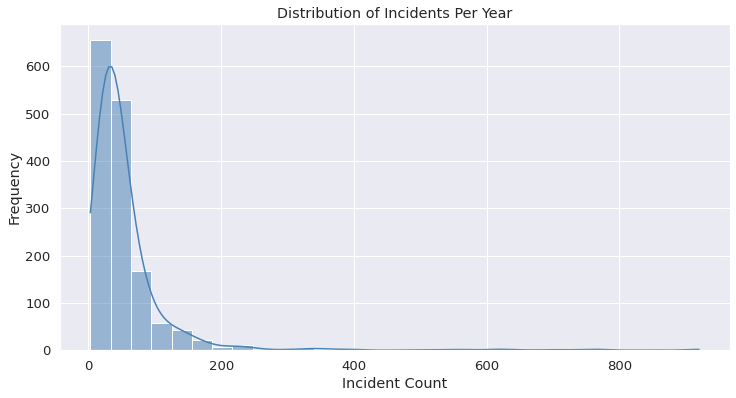

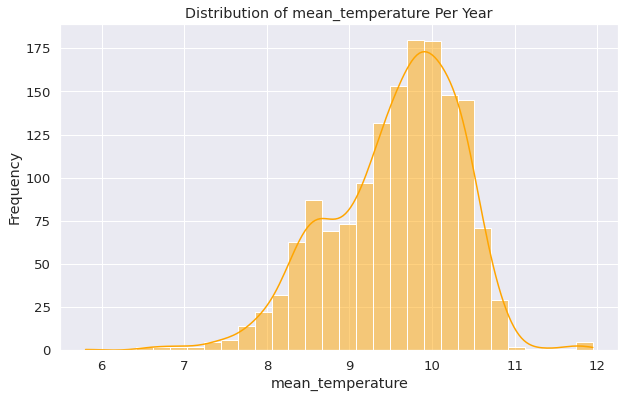

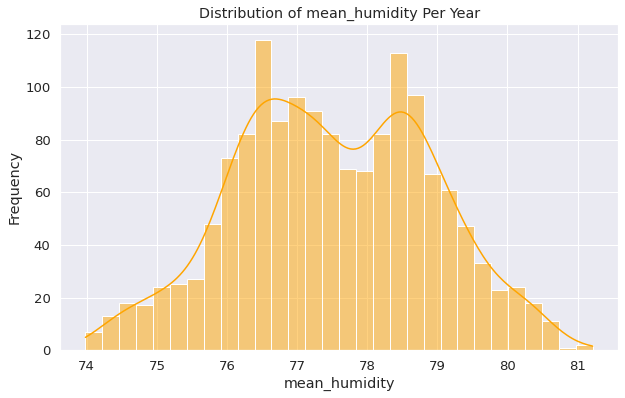

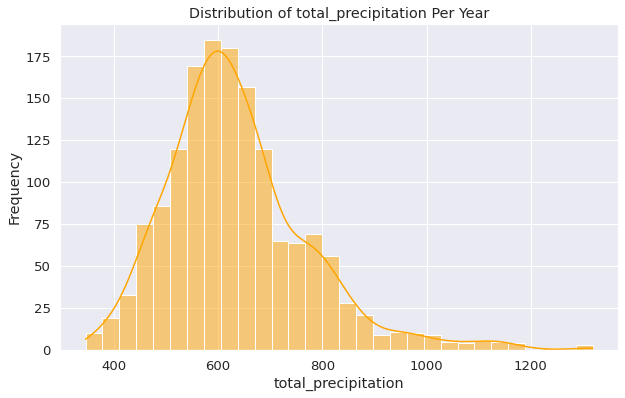

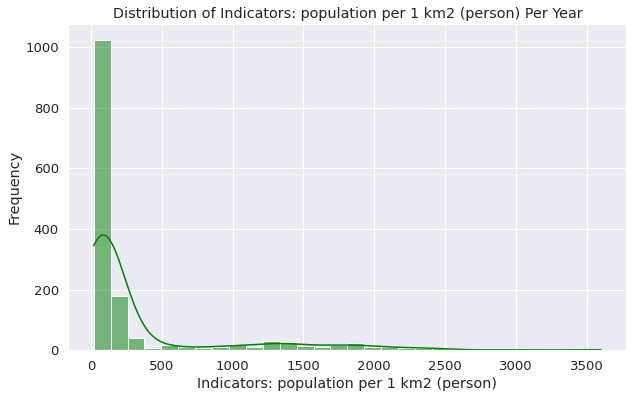

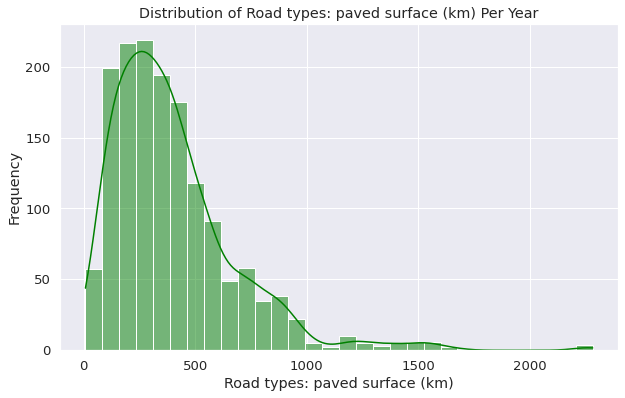

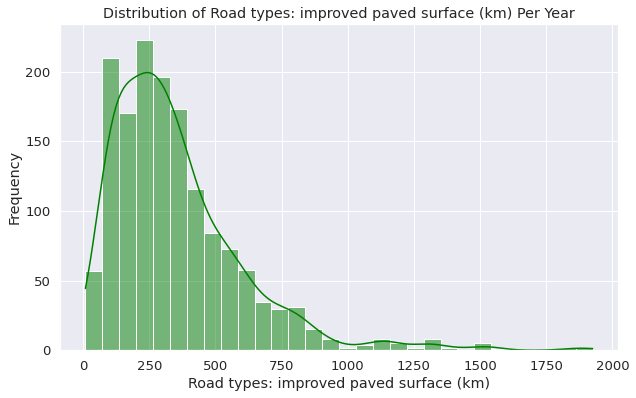

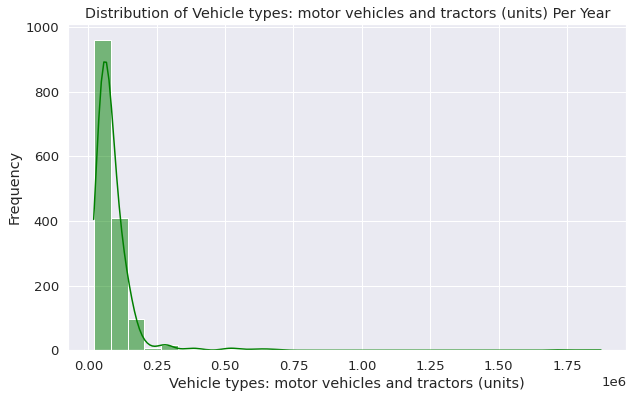

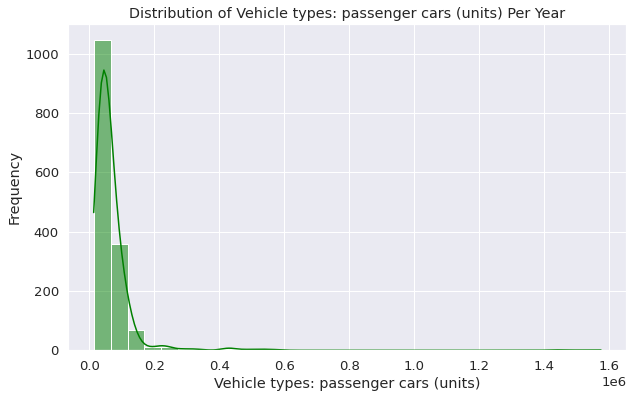

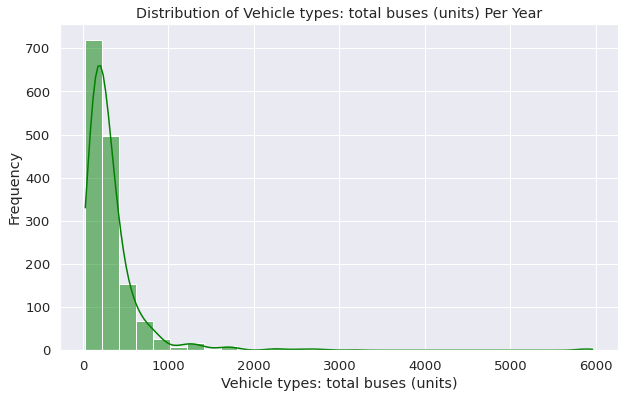

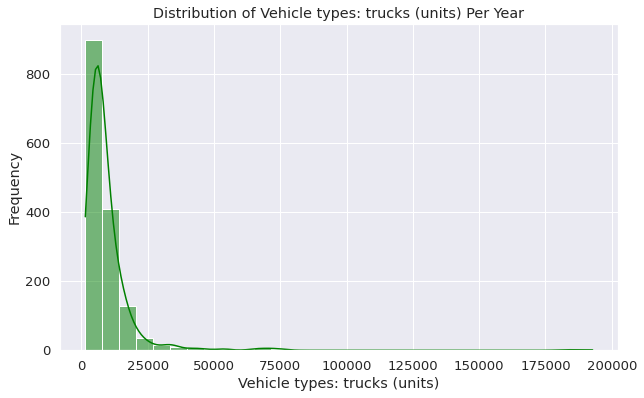

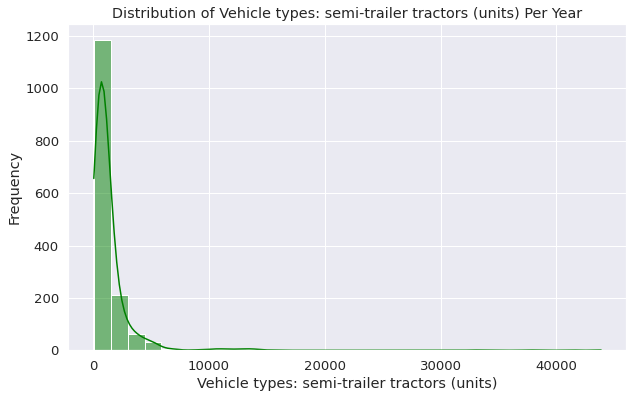

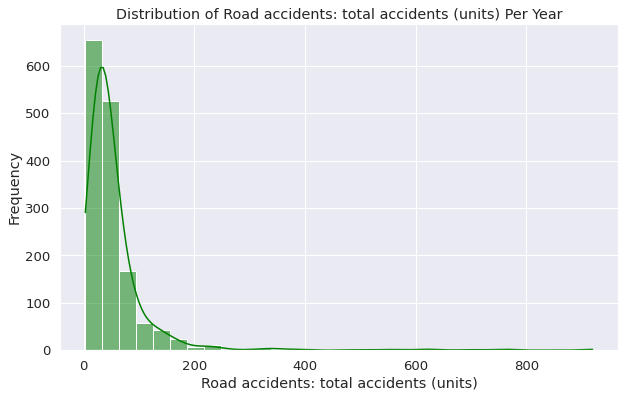

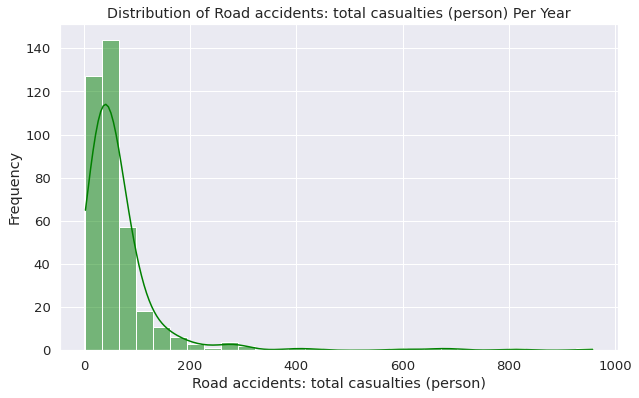

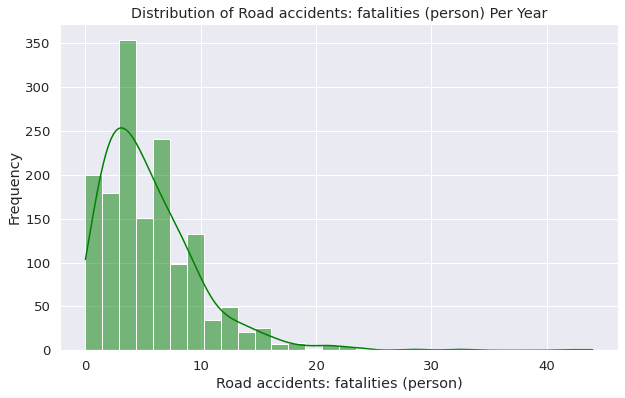

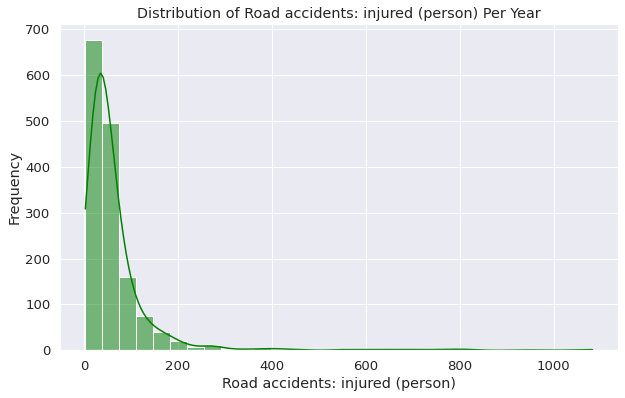

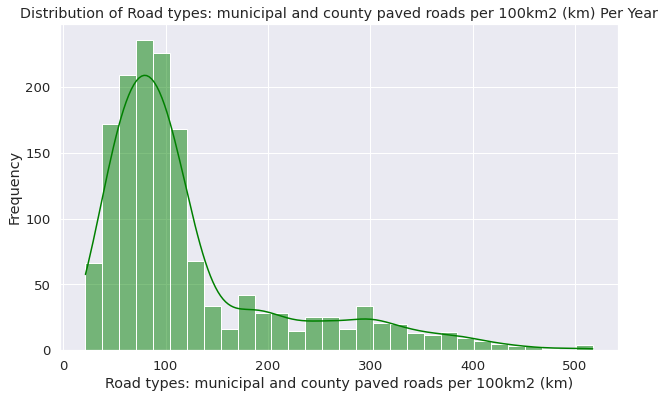

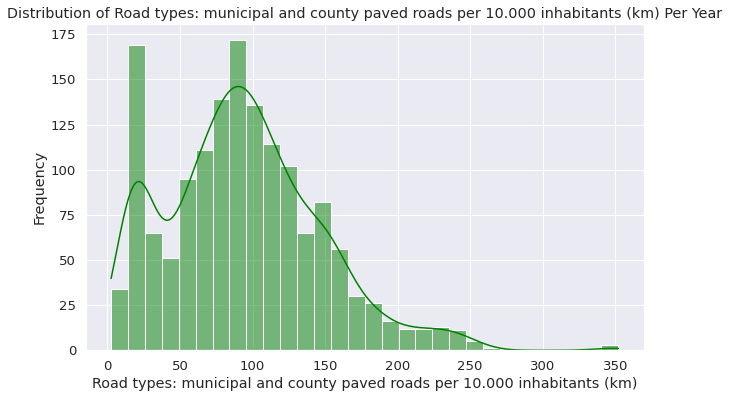

In [10]:
# Create Yearly Aggregations

# Step 1: Process incidents data for yearly aggregation
incidents_count_yearly = incidents_df.groupby(['county', 'voivodeship', 'year']).size().reset_index(name='incident_count')

# Step 2: Process weather data for yearly aggregation
weather_yearly = weather_df.groupby(['county', 'voivodeship', 'year']).agg({
    'temperature': 'mean',
    'humidity': 'mean',
    'precipation': 'sum'
}).reset_index()

# Step 3: Create yearly analysis dataframe
analysis_yearly_df = weather_yearly.copy()

# Merge with incident counts (left join to keep all weather entries)
analysis_yearly_df = pd.merge(
    analysis_yearly_df,
    incidents_count_yearly,
    on=['county', 'voivodeship', 'year'],
    how='left'
)

# Fill missing incident counts with 0 (counties with no incidents that year)
analysis_yearly_df['incident_count'] = analysis_yearly_df['incident_count'].fillna(0).astype(int)

# Merge with socioeconomic data
analysis_yearly_df = pd.merge(
    analysis_yearly_df,
    socio_df,
    on=['county', 'voivodeship', 'year'],
    how='left'
)

# Rename columns for clarity
analysis_yearly_df = analysis_yearly_df.rename(columns={
    'temperature': 'mean_temperature',
    'humidity': 'mean_humidity',
    'precipation': 'total_precipitation'
})

# Display the result shape and first few rows
print(f"Yearly Analysis DataFrame Shape: {analysis_yearly_df.shape}")
print(analysis_yearly_df.head())

# Visualize the distribution of incidents per year
plt.figure(figsize=(12, 6))
sns.histplot(analysis_yearly_df['incident_count'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Incidents Per Year')
plt.xlabel('Incident Count')
plt.ylabel('Frequency')
plt.show()

# Visualize the distribution of weather data per year
weather_cols = ['mean_temperature', 'mean_humidity', 'total_precipitation']
for col in weather_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(analysis_yearly_df[col], bins=30, kde=True, color='orange')
    plt.title(f'Distribution of {col} Per Year')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Visualize the distribution of socioeconomic data per year
socio_cols = socio_df.columns[3:]  # Assuming first three columns are identifiers
for col in socio_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(analysis_yearly_df[col], bins=30, kde=True, color='green')
    plt.title(f'Distribution of {col} Per Year')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Data Cleaning and Selection
Rename columns for clarity, handle missing values, and select relevant features for analysis and modeling.

In [11]:
# Data Cleaning and Selection

# Rename columns for clarity
column_mapping = {
    'Indicators: population per 1 km2 (person)': 'population_density',
    'Road types: paved surface (km)': 'paved_roads',
    'Road types: improved paved surface (km)': 'improved_roads',
    'Vehicle types: motor vehicles and tractors (units)': 'total_vehicles',
    'Vehicle types: passenger cars (units)': 'passenger_cars',
    'Vehicle types: total buses (units)': 'buses',
    'Vehicle types: trucks (units)': 'trucks',
    'Vehicle types: semi-trailer tractors (units)': 'semi_trailers',
    'Road types: municipal and county paved roads per 100km2 (km)': 'road_density',
    'Road types: municipal and county paved roads per 10.000 inhabitants (km)': 'road_per_capita',
    'incident_count': 'incidents'
}

# Apply the column renaming to yearly data
analysis_yearly_df = analysis_yearly_df.rename(columns=column_mapping)

# Apply the column renaming to monthly data
analysis_monthly_df = analysis_monthly_df.rename(columns=column_mapping)

# Handle missing values by dropping rows with any missing values
# analysis_yearly_df.dropna(inplace=True)
# analysis_monthly_df.dropna(inplace=True)

# Reset index after dropping rows
analysis_yearly_df.reset_index(drop=True, inplace=True)
analysis_monthly_df.reset_index(drop=True, inplace=True)

# Select relevant features for analysis and modeling
selected_features_yearly = [
    'county', 'voivodeship', 'year', 'mean_temperature', 'mean_humidity', 'total_precipitation', 
    'population_density', 'paved_roads', 'improved_roads', 'total_vehicles', 'passenger_cars', 
    'buses', 'trucks', 'semi_trailers', 'road_density', 'road_per_capita', 'incidents'
]

selected_features_monthly = [
    'county', 'voivodeship', 'year', 'month', 'year_month', 'mean_temperature', 'mean_humidity', 
    'total_precipitation', 'population_density', 'paved_roads', 'improved_roads', 'total_vehicles', 
    'passenger_cars', 'buses', 'trucks', 'semi_trailers', 'road_density', 'road_per_capita', 'incidents'
]

# Create new dataframes with the selected features
df_yearly = analysis_yearly_df[selected_features_yearly].copy()
df_monthly = analysis_monthly_df[selected_features_monthly].copy()

# Display the first few rows of the cleaned and selected data
print("Cleaned and Selected Yearly DataFrame:")
print(df_yearly.head())
print("\nCleaned and Selected Monthly DataFrame:")
print(df_monthly.head())

Cleaned and Selected Yearly DataFrame:
           county voivodeship  year  mean_temperature  mean_humidity  \
0  Biała Podlaska   lubelskie  2020          9.913629      77.586073   
1  Biała Podlaska   lubelskie  2021          8.327231      79.292413   
2  Biała Podlaska   lubelskie  2022          9.169254      77.391236   
3  Biała Podlaska   lubelskie  2023         10.025624      77.269007   
4       Białystok   podlaskie  2020          9.626115      78.142038   

   total_precipitation  population_density  paved_roads  improved_roads  \
0           606.447431              1124.1        111.5           111.2   
1           543.408860              1115.4        113.0           112.8   
2           587.156298              1108.7        113.7           113.4   
3           558.582515              1102.3        114.4           114.1   
4           608.661994              2885.3        272.2           271.0   

   total_vehicles  passenger_cars   buses   trucks  semi_trailers  \
0       

# Exploratory Data Analysis
Perform detailed exploratory analysis to understand relationships between variables, including correlation analysis and scatterplots between key variables.

EDA for Yearly Data:


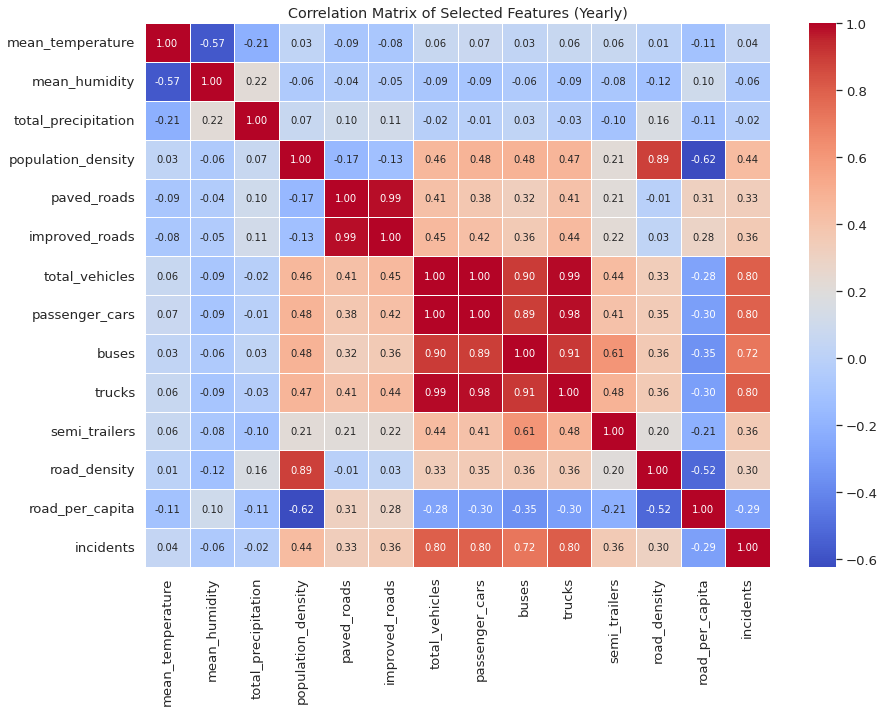

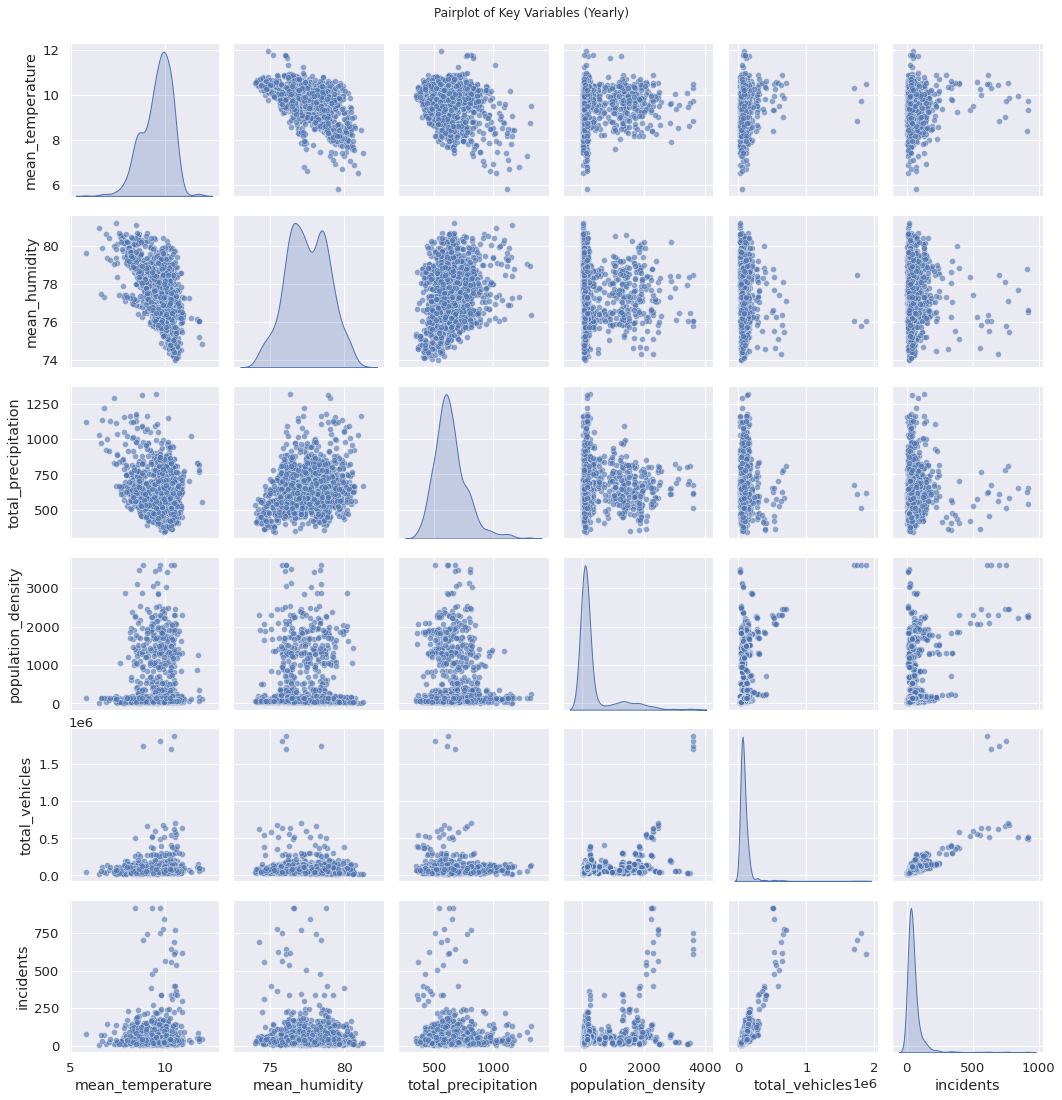

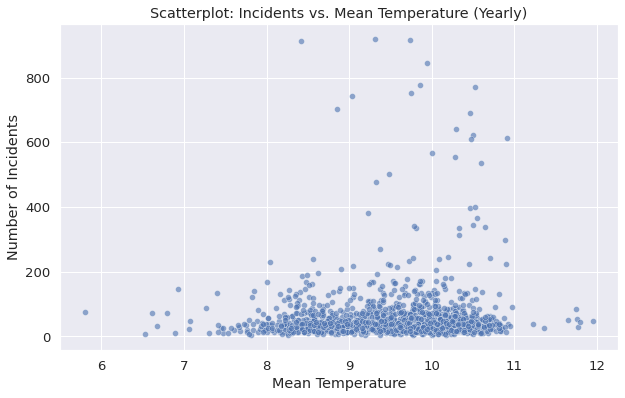

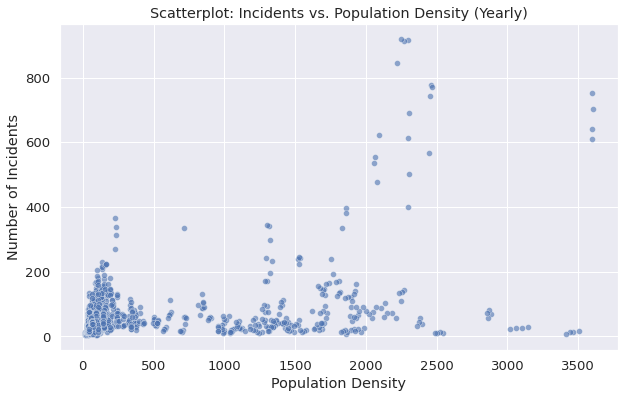

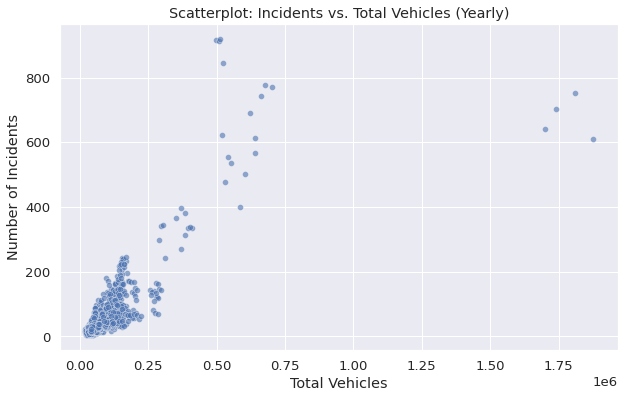


EDA for Monthly Data:


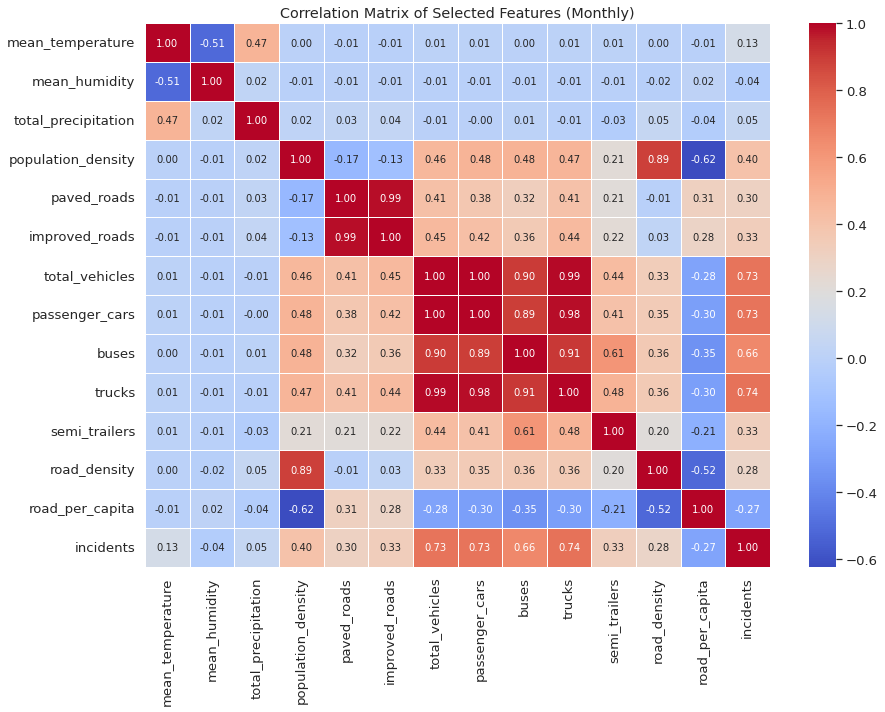

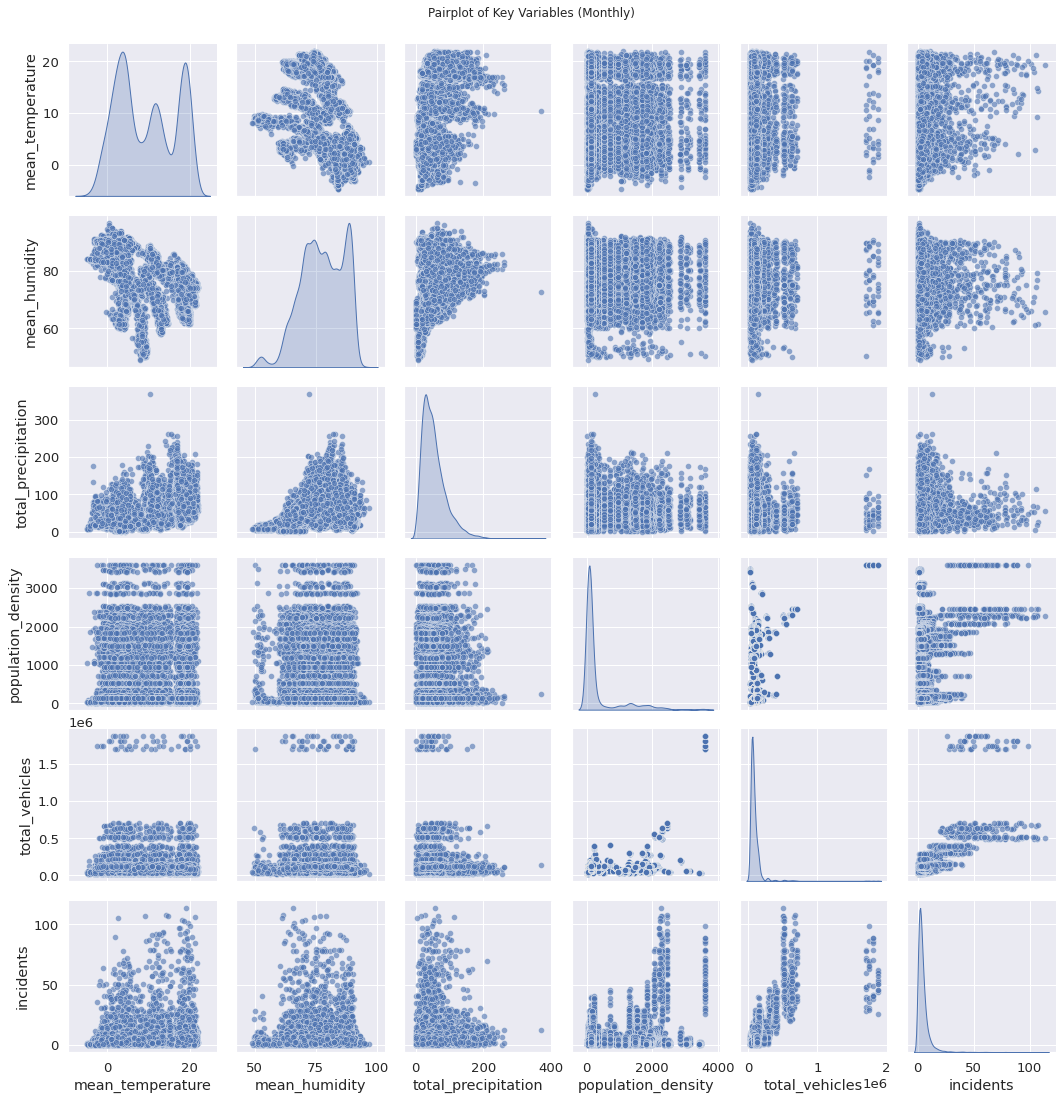

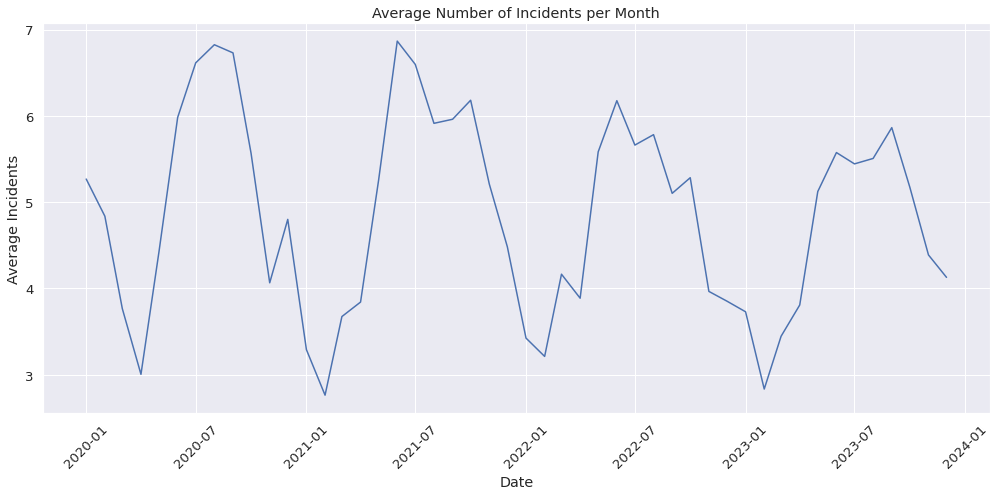

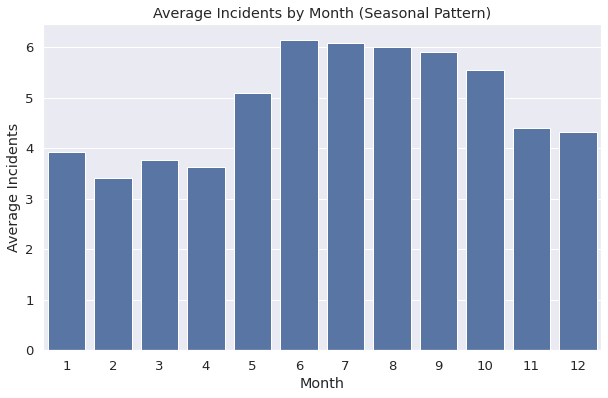

<Figure size 720x432 with 0 Axes>

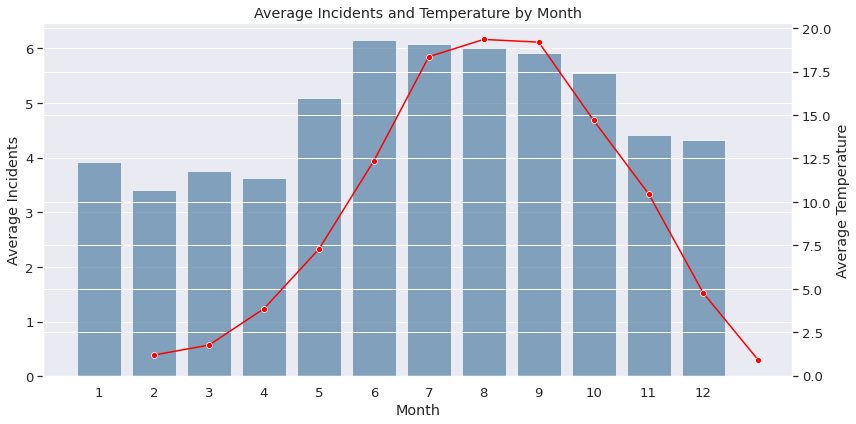

In [12]:
# Exploratory Data Analysis for Yearly and Monthly Data

# ----- YEARLY DATA ANALYSIS -----
print("EDA for Yearly Data:")

# Correlation Analysis - Yearly
plt.figure(figsize=(14, 10))
yearly_correlation_matrix = df_yearly[df_yearly.columns[3:]].corr()
sns.heatmap(yearly_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Selected Features (Yearly)')
plt.show()

# Scatterplots between key variables - Yearly
key_variables_yearly = ['mean_temperature', 'mean_humidity', 'total_precipitation', 'population_density', 'total_vehicles', 'incidents']

# Pairplot for key variables - Yearly
sns.pairplot(df_yearly[key_variables_yearly], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Variables (Yearly)', y=1.02)
plt.show()

# Scatterplot: Incidents vs. Mean Temperature - Yearly
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mean_temperature', y='incidents', data=df_yearly, alpha=0.6)
plt.title('Scatterplot: Incidents vs. Mean Temperature (Yearly)')
plt.xlabel('Mean Temperature')
plt.ylabel('Number of Incidents')
plt.show()

# Scatterplot: Incidents vs. Population Density - Yearly
plt.figure(figsize=(10, 6))
sns.scatterplot(x='population_density', y='incidents', data=df_yearly, alpha=0.6)
plt.title('Scatterplot: Incidents vs. Population Density (Yearly)')
plt.xlabel('Population Density')
plt.ylabel('Number of Incidents')
plt.show()

# Scatterplot: Incidents vs. Total Vehicles - Yearly
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_vehicles', y='incidents', data=df_yearly, alpha=0.6)
plt.title('Scatterplot: Incidents vs. Total Vehicles (Yearly)')
plt.xlabel('Total Vehicles')
plt.ylabel('Number of Incidents')
plt.show()

# ----- MONTHLY DATA ANALYSIS -----
print("\nEDA for Monthly Data:")

# Correlation Analysis - Monthly
plt.figure(figsize=(14, 10))
monthly_correlation_matrix = df_monthly[df_monthly.columns[5:]].corr()  # Skip county, voivodeship, year, month, year_month
sns.heatmap(monthly_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Selected Features (Monthly)')
plt.show()

# Scatterplots between key variables - Monthly
key_variables_monthly = ['mean_temperature', 'mean_humidity', 'total_precipitation', 'population_density', 'total_vehicles', 'incidents']

# Pairplot for key variables - Monthly
sns.pairplot(df_monthly[key_variables_monthly], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Variables (Monthly)', y=1.02)
plt.show()

# Monthly incidents over time
plt.figure(figsize=(14, 7))
monthly_avg = df_monthly.groupby('year_month')['incidents'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg['year_month'] + '-01')
monthly_avg = monthly_avg.sort_values('date')
sns.lineplot(x='date', y='incidents', data=monthly_avg)
plt.title('Average Number of Incidents per Month')
plt.xlabel('Date')
plt.ylabel('Average Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Seasonal patterns - Monthly
plt.figure(figsize=(10, 6))
monthly_by_month = df_monthly.groupby('month')['incidents'].mean().reset_index()
sns.barplot(x='month', y='incidents', data=monthly_by_month)
plt.title('Average Incidents by Month (Seasonal Pattern)')
plt.xlabel('Month')
plt.ylabel('Average Incidents')
plt.show()

# Temperature vs. Incidents by Month
plt.figure(figsize=(10, 6))
month_temp_incidents = df_monthly.groupby('month')[['mean_temperature', 'incidents']].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
sns.barplot(x='month', y='incidents', data=month_temp_incidents, color='steelblue', alpha=0.7, ax=ax1)
sns.lineplot(x='month', y='mean_temperature', data=month_temp_incidents, color='red', marker='o', ax=ax2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Incidents')
ax2.set_ylabel('Average Temperature')
plt.title('Average Incidents and Temperature by Month')
plt.tight_layout()
plt.show()

# Data Normalization
Apply appropriate normalization techniques to different feature types - standardization for weather parameters and log transformation for socioeconomic variables with skewed distributions.

Normalizing Yearly Data:


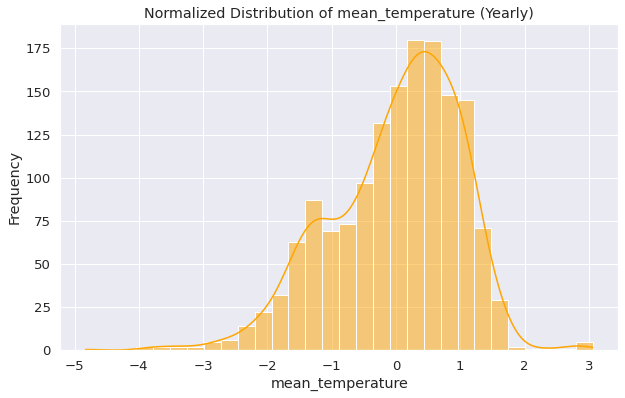

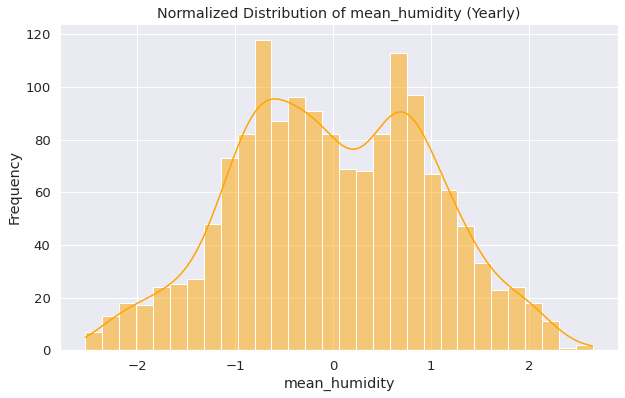

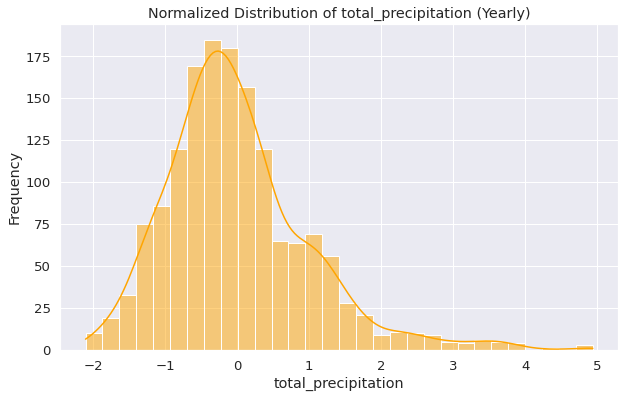


Normalizing Monthly Data:


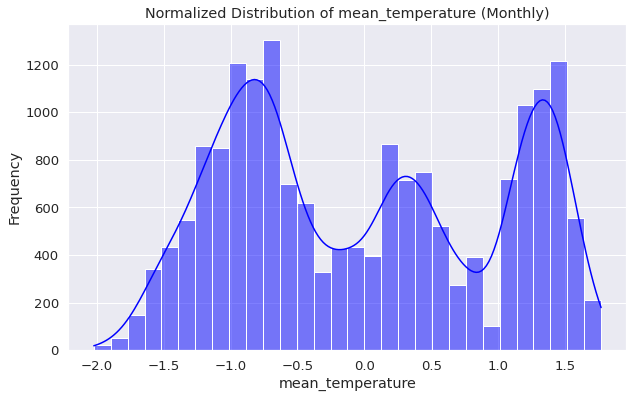

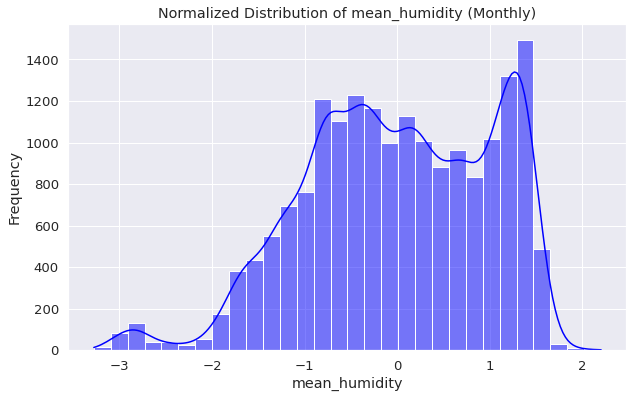

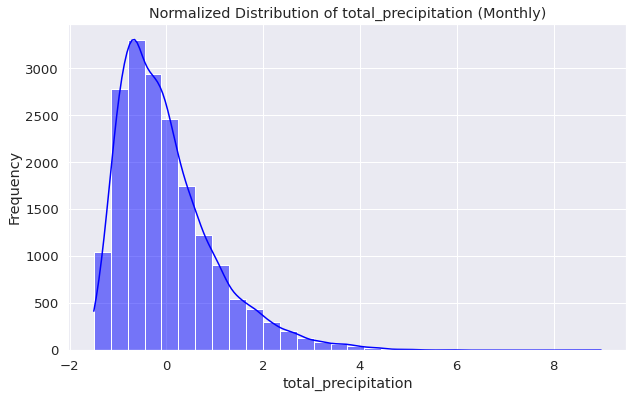


Yearly Data Summary After Normalization:
              year  mean_temperature  mean_humidity  total_precipitation  \
count  1524.000000      1.524000e+03   1.524000e+03         1.524000e+03   
mean   2021.500000     -3.298615e-16   4.615730e-16         4.475860e-16   
std       1.118401      1.000000e+00   1.000000e+00         1.000000e+00   
min    2020.000000     -4.828374e+00  -2.530985e+00        -2.107461e+00   
25%    2020.750000     -6.176400e-01  -7.358916e-01        -6.447864e-01   
50%    2021.500000      1.711465e-01  -4.120880e-02        -1.525570e-01   
75%    2022.250000      7.402969e-01   7.522511e-01         4.408870e-01   
max    2023.000000      3.062610e+00   2.649001e+00         4.940945e+00   

       population_density  paved_roads  improved_roads  total_vehicles  \
count         1520.000000  1520.000000     1520.000000     1520.000000   
mean             4.900999     5.765972        5.633790       11.200431   
std              1.228385     0.705416        0.710

In [13]:
# Data Normalization for Yearly and Monthly Data

# ----- YEARLY DATA NORMALIZATION -----
print("Normalizing Yearly Data:")

# Standardize weather parameters - Yearly
weather_params = ['mean_temperature', 'mean_humidity', 'total_precipitation']
df_yearly[weather_params] = df_yearly[weather_params].apply(lambda x: (x - x.mean()) / x.std())

# Apply log transformation to socioeconomic variables with skewed distributions - Yearly
socio_params = ['population_density', 'paved_roads', 'improved_roads', 'total_vehicles', 
                'passenger_cars', 'buses', 'trucks', 'semi_trailers', 'road_density', 'road_per_capita']
df_yearly[socio_params] = df_yearly[socio_params].apply(lambda x: np.log1p(x))

# Visualize the normalized weather parameters - Yearly
for param in weather_params:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_yearly[param], bins=30, kde=True, color='orange')
    plt.title(f'Normalized Distribution of {param} (Yearly)')
    plt.xlabel(param)
    plt.ylabel('Frequency')
    plt.show()

# ----- MONTHLY DATA NORMALIZATION -----
print("\nNormalizing Monthly Data:")

# Standardize weather parameters - Monthly
df_monthly[weather_params] = df_monthly[weather_params].apply(lambda x: (x - x.mean()) / x.std())

# Apply log transformation to socioeconomic variables with skewed distributions - Monthly
df_monthly[socio_params] = df_monthly[socio_params].apply(lambda x: np.log1p(x))

# Visualize the normalized weather parameters - Monthly
for param in weather_params:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_monthly[param], bins=30, kde=True, color='blue')
    plt.title(f'Normalized Distribution of {param} (Monthly)')
    plt.xlabel(param)
    plt.ylabel('Frequency')
    plt.show()

# Check for any remaining issues after normalization
print("\nYearly Data Summary After Normalization:")
print(df_yearly.describe())
print("\nMonthly Data Summary After Normalization:")
print(df_monthly.describe())

# Drop NaNs

In [14]:
analysis_monthly_df.dropna(inplace=True)
analysis_yearly_df.dropna(inplace=True)

df_monthly.dropna(inplace=True)
df_yearly.dropna(inplace=True)

# Export Processed Data
Save the processed and normalized datasets to files for use in modeling notebooks.

In [15]:
# Export Processed Data

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define output file paths
monthly_output_path = OUTPUT_DIR / "processed_monthly_data.csv"
yearly_output_path = OUTPUT_DIR / "processed_yearly_data.csv"
monthly_norm_output_path = OUTPUT_DIR / "normalized_monthly_data.csv"
yearly_norm_output_path = OUTPUT_DIR / "normalized_yearly_data.csv"

# Save the processed data (before normalization)
analysis_monthly_df.to_csv(monthly_output_path, index=False)
analysis_yearly_df.to_csv(yearly_output_path, index=False)
print(f"Processed monthly data saved to: {monthly_output_path}")
print(f"Processed yearly data saved to: {yearly_output_path}")

# Save the normalized data
df_monthly.to_csv(monthly_norm_output_path, index=False)
df_yearly.to_csv(yearly_norm_output_path, index=False)
print(f"Normalized monthly data saved to: {monthly_norm_output_path}")
print(f"Normalized yearly data saved to: {yearly_norm_output_path}")

Processed monthly data saved to: /project/data/analysis/processed_monthly_data.csv
Processed yearly data saved to: /project/data/analysis/processed_yearly_data.csv
Normalized monthly data saved to: /project/data/analysis/normalized_monthly_data.csv
Normalized yearly data saved to: /project/data/analysis/normalized_yearly_data.csv


In [16]:
df_monthly

,county,voivodeship,year,month,year_month,mean_temperature,mean_humidity,total_precipitation,population_density,paved_roads,improved_roads,total_vehicles,passenger_cars,buses,trucks,semi_trailers,road_density,road_per_capita,incidents
0,Biała Podlaska,lubelskie,2020,1,2020-01,-1.103066,1.113782,-1.103960,7.025627,4.722953,4.720283,10.777163,10.526346,5.247024,8.510571,7.386471,5.783517,3.394508,2
1,Biała Podlaska,lubelskie,2020,2,2020-02,-0.870175,0.271518,-0.131636,7.025627,4.722953,4.720283,10.777163,10.526346,5.247024,8.510571,7.386471,5.783517,3.394508,3
2,Biała Podlaska,lubelskie,2020,3,2020-03,-0.739379,-1.201007,-1.074892,7.025627,4.722953,4.720283,10.777163,10.526346,5.247024,8.510571,7.386471,5.783517,3.394508,2
3,Biała Podlaska,lubelskie,2020,4,2020-04,-0.160264,-2.753079,-1.348440,7.025627,4.722953,4.720283,10.777163,10.526346,5.247024,8.510571,7.386471,5.783517,3.394508,0
4,Biała Podlaska,lubelskie,2020,5,2020-05,0.250216,-0.700083,0.976764,7.025627,4.722953,4.720283,10.777163,10.526346,5.247024,8.510571,7.386471,5.783517,3.394508,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18283,żywiecki,śląskie,2023,8,2023-08,1.212070,0.230947,3.413033,4.970508,6.503689,6.463341,11.714461,11.463231,6.376727,9.444543,7.053586,4.585987,4.232656,6
18284,żywiecki,śląskie,2023,9,2023-09,0.900187,0.251559,0.648422,4.970508,6.503689,6.463341,11.714461,11.463231,6.376727,9.444543,7.053586,4.585987,4.232656,5
18285,żywiecki,śląskie,2023,10,2023-10,0.182824,0.428342,1.904775,4.970508,6.503689,6.463341,11.714461,11.463231,6.376727,9.444543,7.053586,4.585987,4.232656,2
18286,żywiecki,śląskie,2023,11,2023-11,-0.691626,0.581183,2.903910,4.970508,6.503689,6.463341,11.714461,11.463231,6.376727,9.444543,7.053586,4.585987,4.232656,3


Socioeconomic Country Data - Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 17 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   id                                                                        9 non-null      int64  
 1   name                                                                      9 non-null      object 
 2   year                                                                      9 non-null      int64  
 3   Indicators: population per 1 km2 (person)                                 9 non-null      float64
 4   Road types: paved surface (km)                                            9 non-null      float64
 5   Road types: improved paved surface (km)                                   9 non-null      float64
 6   Vehicle types: motor vehicles

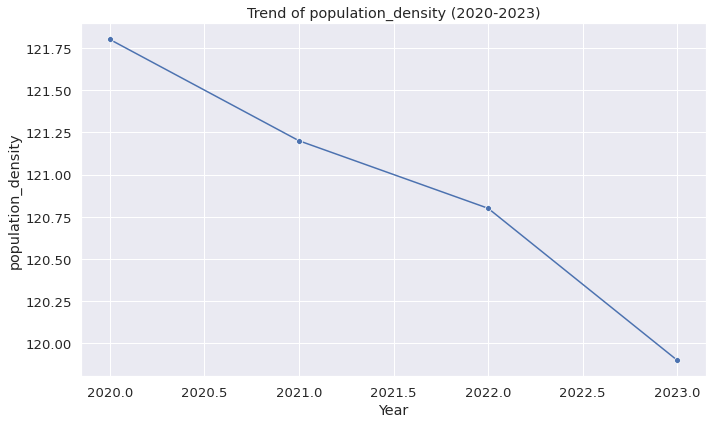

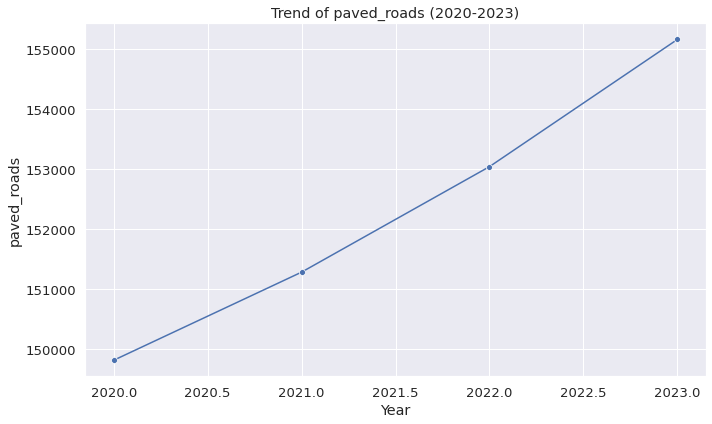

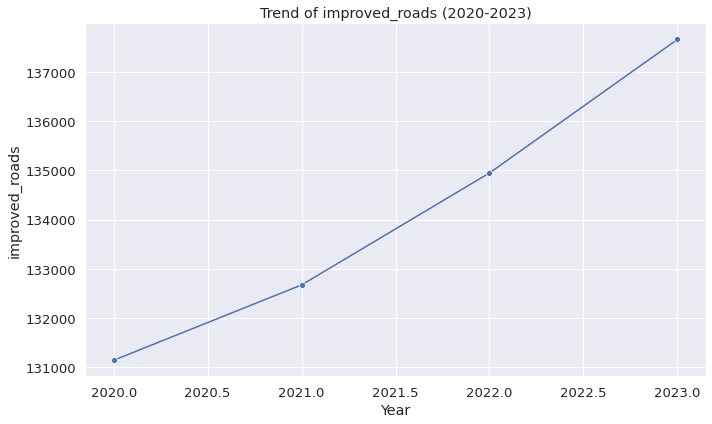

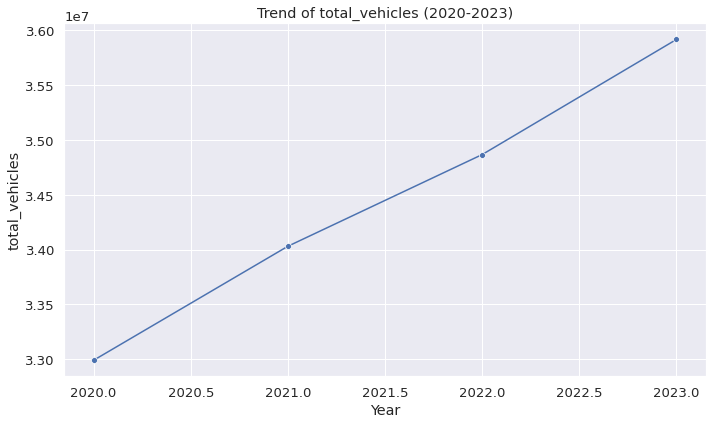

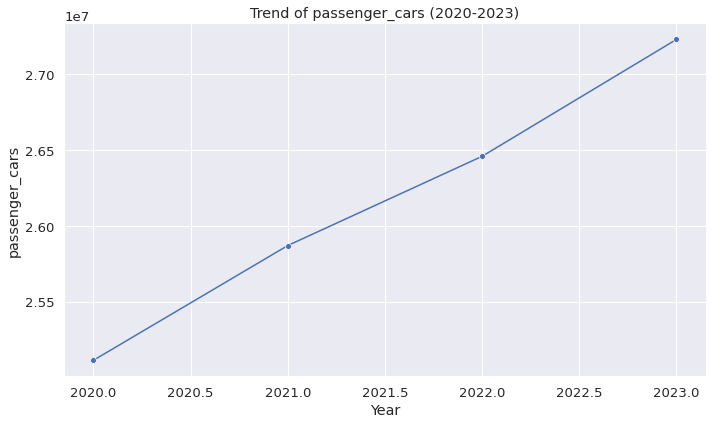

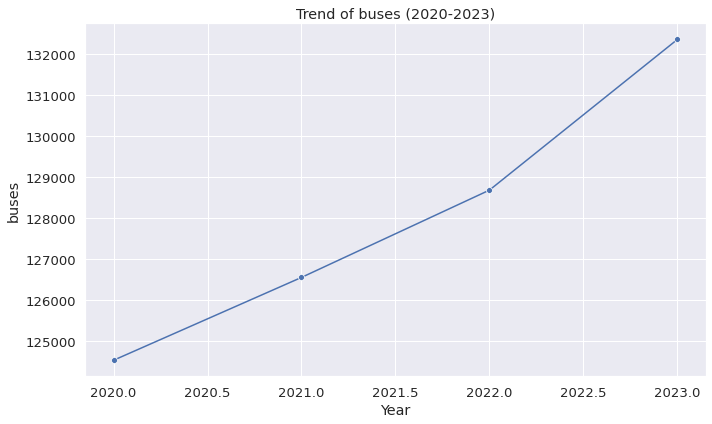

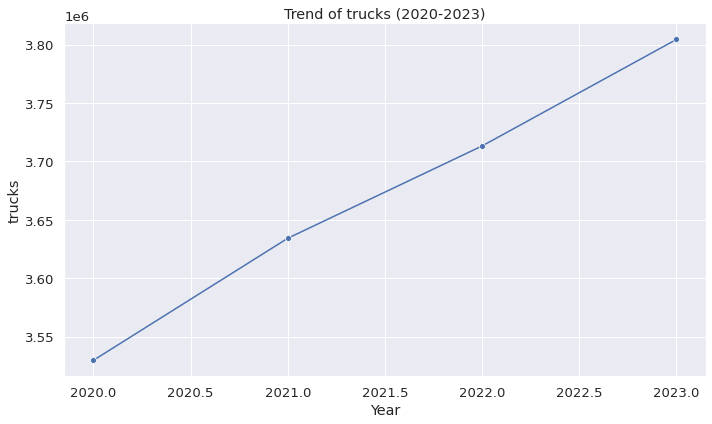

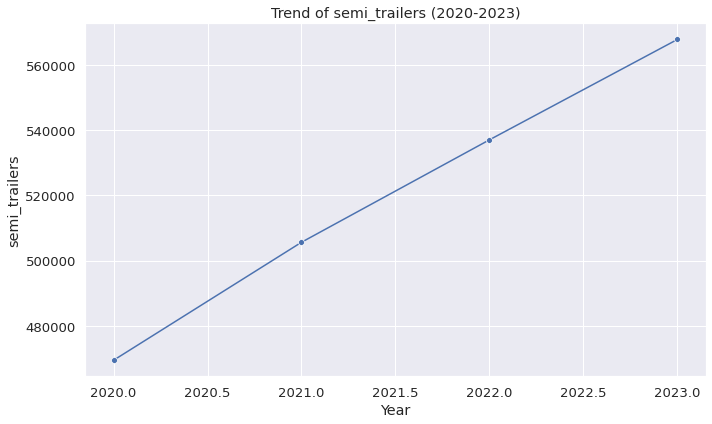

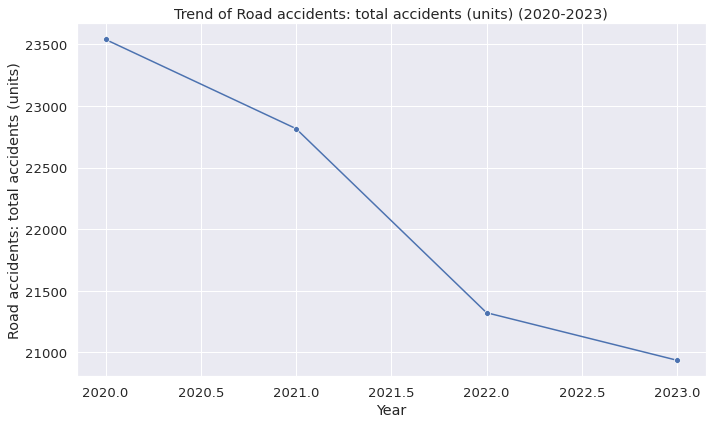

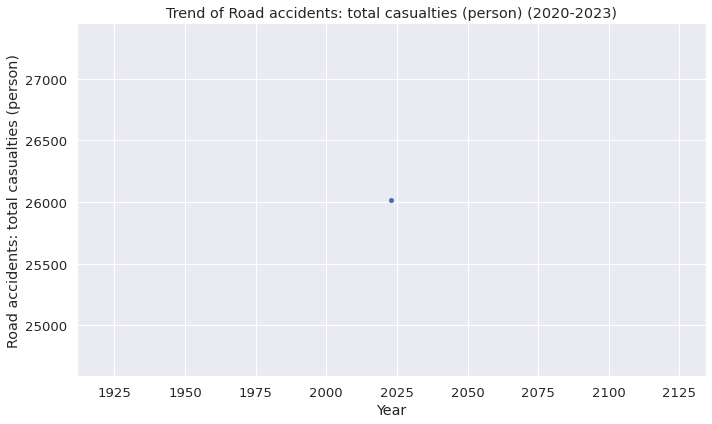

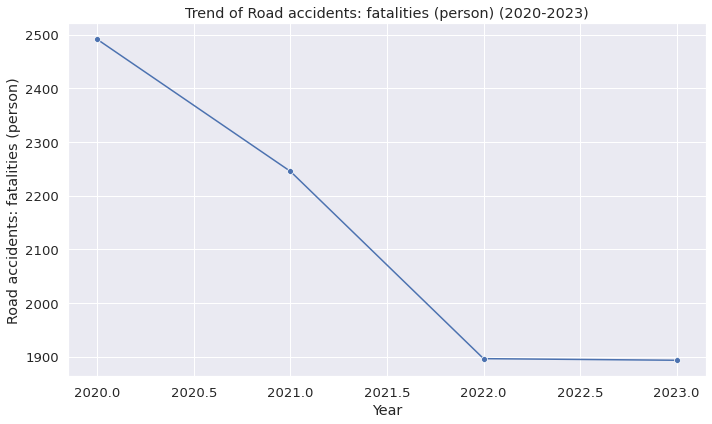

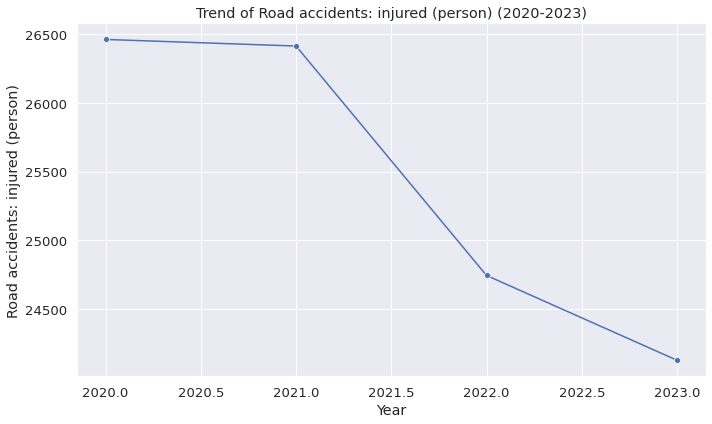

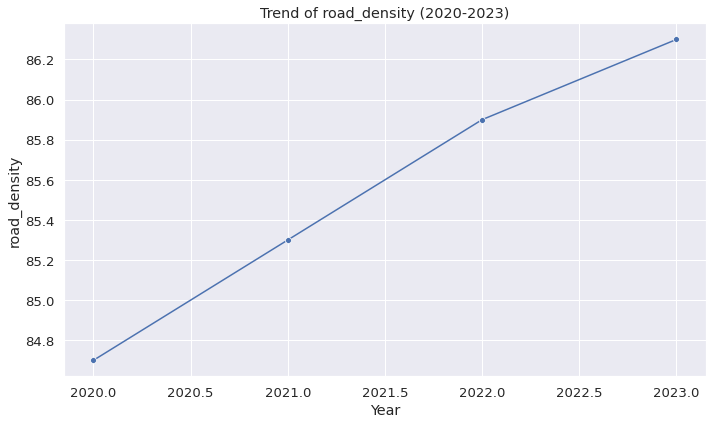

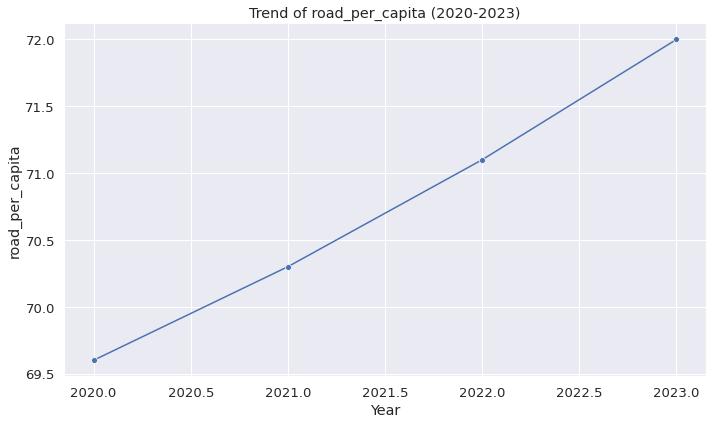

In [21]:
# Load country socioeconomic data
socio_country_df = pd.read_csv(DATA_DIR / 'processed/socioeconomic_country.csv')

# Display basic information
print("Socioeconomic Country Data - Basic Info:")
print(socio_country_df.info())
print("\nFirst few rows:")
print(socio_country_df.head())

# Check for missing values
print("\nMissing values:")
print(socio_country_df.isnull().sum())

# Filter for years 2020 and later to match other datasets
socio_country_df = socio_country_df[socio_country_df.year >= 2020]

# Rename columns using the same mapping as other socioeconomic data
socio_country_df = socio_country_df.rename(columns=column_mapping)

# Select numerical columns for normalization (excluding id, name, year)
numerical_cols = socio_country_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', 'year']]

# Visualize distributions before normalization
# for col in numerical_cols:
#     plt.figure(figsize=(10, 6))
#     sns.histplot(socio_country_df[col], kde=True)
#     plt.title(f'Distribution of {col}')
#     plt.tight_layout()
#     plt.show()

# Apply min-max normalization (0-1 scale)
socio_country_norm_df = socio_country_df.copy()
for col in numerical_cols:
    min_val = socio_country_df[col].min()
    max_val = socio_country_df[col].max()
    socio_country_norm_df[col] = (socio_country_df[col] - min_val) / (max_val - min_val)

# Visualize distributions after normalization
# for col in numerical_cols:
#     plt.figure(figsize=(10, 6))
#     sns.histplot(socio_country_norm_df[col], kde=True)
#     plt.title(f'Normalized Distribution of {col} (Min-Max)')
#     plt.tight_layout()
#     plt.show()

# Save the normalized data
normalized_country_output_path = OUTPUT_DIR / "normalized_socioeconomic_country.csv"
socio_country_norm_df.to_csv(normalized_country_output_path, index=False)
print(f"Normalized country socioeconomic data saved to: {normalized_country_output_path}")

# Time series plots for each variable to visualize trends over years
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='year', y=col, data=socio_country_df, marker='o')
    plt.title(f'Trend of {col} (2020-2023)')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
